# IC3392 OIII5006 high-S/N outlier inspection: SIII9068-only gas-list test


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from astropy.io import fits

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 260)
pd.set_option('display.max_colwidth', 180)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 160,
    'axes.grid': False,
})

root = Path.cwd()
GALAXY = 'IC3392'
OIII_LINE = 'OIII5006'
OIII_LABEL = '[O III] 5006'
OIII_REST_A = 5006.843
REDSHIFT = 0.005566
C_KMS = 299792.458

LINE_DEFS = {
    'OIII5006': {'label': '[O III] 5006', 'rest_air_a': 5006.843, 'wave_half_width': 45.0, 'line_half_width': 12.0},
    'SIII9068': {'label': '[S III] 9068', 'rest_air_a': 9068.60, 'wave_half_width': 45.0, 'line_half_width': 14.0},
}
SPECTRAL_LINE_IDS = ['OIII5006', 'SIII9068']

RUNS = {
    'v768_7000_53_samebinning': {
        'label': 'v3tk_v7.6.8 7000/53 setup, same binning as 9100/40',
        'plot_label': '7.6.8 7000/53 same-bin',
        'gas_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'gas_bestfit_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_gas_bestfit_bin.fits',
        'line_cube_path': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_line_cube.fits',
        'color': '#1f77b4',
    },
    'v768_9100_40_use_SIII9068': {
        'label': 'v3tk_v7.6.8 9100/40, used lines with SIII9068 only; no SIII6312 or ArIII7135',
        'plot_label': '7.6.8 9100/40 SIII9068-only',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_use_SIII9068' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
        'gas_bestfit_path': root / 'v3tk_v7.6.8_VELSCALE40_use_SIII9068' / GALAXY / f'{GALAXY}_gas_bestfit_bin.fits',
        'line_cube_path': None,
        'color': '#d62728',
    },
}
BASELINE_RUN = 'v768_7000_53_samebinning'
COMPARE_RUN = 'v768_9100_40_use_SIII9068'
RUN_ORDER = [BASELINE_RUN, COMPARE_RUN]
BESTFIT_RUNS = RUN_ORDER
LINECUBE_RUN = BASELINE_RUN
RUN_PREFIX = {BASELINE_RUN: 'ref', COMPARE_RUN: 'cmp'}

SNR_CUTS = [0, 3, 5, 10, 20, 50]
HIGH_SNR_CUT = 20
N_TOP_SIGMA = 6
N_TOP_VEL = 6
N_SPECTRA_TO_PLOT = 10

run_table = []
for run_key, run in RUNS.items():
    gas_path = run['gas_path']
    bestfit_path = run['gas_bestfit_path']
    line_cube_path = run['line_cube_path']
    run_table.append({
        'run_key': run_key,
        'label': run['label'],
        'gas_path': str(gas_path.relative_to(root)),
        'gas_exists': gas_path.exists(),
        'gas_size_MB': gas_path.stat().st_size / 1024**2 if gas_path.exists() else np.nan,
        'gas_bestfit_path': str(bestfit_path.relative_to(root)),
        'gas_bestfit_exists': bestfit_path.exists(),
        'gas_bestfit_size_MB': bestfit_path.stat().st_size / 1024**2 if bestfit_path.exists() else np.nan,
        'line_cube_path': str(line_cube_path.relative_to(root)) if line_cube_path else '',
        'line_cube_exists': bool(line_cube_path and line_cube_path.exists()),
        'line_cube_size_GB': line_cube_path.stat().st_size / 1024**3 if line_cube_path and line_cube_path.exists() else np.nan,
    })
run_table = pd.DataFrame(run_table)
display(run_table)
assert run_table['gas_exists'].all(), 'Missing one or more GAS map files.'
assert run_table['gas_bestfit_exists'].all(), 'Missing one or more GAS_BESTFIT files.'
assert run_table.loc[run_table['run_key'].eq(LINECUBE_RUN), 'line_cube_exists'].all(), 'Missing the same-bin line cube.'


,run_key,label,gas_path,gas_exists,gas_size_MB,gas_bestfit_path,gas_bestfit_exists,gas_bestfit_size_MB,line_cube_path,line_cube_exists,line_cube_size_GB
0,v768_7000_53_samebinning,"v3tk_v7.6.8 7000/53 setup, same binning as 9100/40",v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_gas_bin_maps.fits,True,152.251282,v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_gas_bestfit_bin.fits,True,169.790955,v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_line_cube.fits,True,2.466423
1,v768_9100_40_use_SIII9068,"v3tk_v7.6.8 9100/40, used lines with SIII9068 only; no SIII6312 or ArIII7135",v3tk_v7.6.8_VELSCALE40_use_SIII9068/IC3392/IC3392_gas_bin_maps.fits,True,172.746277,v3tk_v7.6.8_VELSCALE40_use_SIII9068/IC3392/IC3392_gas_bestfit_bin.fits,True,294.952698,,False,NaN


## Why This Test Is Careful

The hypothesis being tested is: if the 9100/40 rerun keeps the same useful line list but fits only `SIII9068` among the SIII/ArIII red lines, the OIII5006 high-S/N outlier behavior should show whether `SIII9068` alone can still pull the shared kinematics away from the `7000/53 same-bin` reference.

This notebook compares:

- reference: `v3tk_v7.6.8_7000_samebinning`, the 7000/53 setup rerun on the same binning scheme.
- comparison: `v3tk_v7.6.8_VELSCALE40_use_SIII9068`, the 9100/40 used-line setup with `SIII9068` active, but `SIII6312` and `ArIII7135` inactive.

The OIII ranking and map/pairwise diagnostics follow the 0513/0514 notebooks. The spectral quick-look is updated: it uses the real continuum-subtracted `IC3392_line_cube.fits` from the 7000 same-bin folder and overlays the stored `GAS_BESTFIT` spectra from each run. No Gaussian model is reconstructed from map values.

Only two spectral windows are shown: `OIII5006` and `SIII9068`.


In [2]:
CONFIG_PATHS = {
    'reference_7000_53_samebinning': root / 'v3tk_v7.6.8_7000_samebinning' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_7000_samebinning_setonix.yaml',
    'full_9100_40_previous': root / 'v3tk_v7.6.8_VELSCALE40' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_setonix.yaml',
    'plain_use_9100_40_previous': root / 'v3tk_v7.6.8_VELSCALE40_use' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_setonix.yaml',
    'ariii_no_siii_9100_40_previous': root / 'v3tk_v7.6.8_VELSCALE40_use_ArIII_noSIII' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_ArIII_noSIII_setonix.yaml',
    'use_trick_9100_40_previous': root / 'v3tk_v7.6.8_VELSCALE40_use_trick' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_trick_setonix.yaml',
    'use_SIII9068_9100_40_comparison': root / 'v3tk_v7.6.8_VELSCALE40_use_SIII9068' / GALAXY / f'{GALAXY}_MAUVE_MasterConfig_v7.6.8_VELSCALE40_use_SIII9068_setonix.yaml',
}
EMISSION_CONFIGS = {
    'full': root / 'emissionLines_ppxf_full.config',
    'use': root / 'emissionLines_ppxf_use.config',
    'use_ArIII_noSIII': root / 'emissionLines_ppxf_use_ArIII_noSIII.config',
    'use_trick': root / 'emissionLines_ppxf_use_trick.config',
    'use_SIII9068': root / 'emissionLines_ppxf_use_SIII9068.config',
}
COMPARISON_EMISSION_CONFIG_KEY = 'use_SIII9068'


def read_simple_yaml(path):
    import yaml
    with open(path, 'r') as handle:
        return yaml.safe_load(handle)


def cfg_value(config, dotted_key):
    value = config
    for key in dotted_key.split('.'):
        if not isinstance(value, dict) or key not in value:
            return np.nan
        value = value[key]
    return value


def parse_emission_config(path):
    rows = []
    for lineno, raw_line in enumerate(path.read_text().splitlines(), start=1):
        stripped = raw_line.strip()
        if not stripped:
            continue
        commented = stripped.startswith('#')
        content = stripped.lstrip('#').strip() if commented else stripped
        parts = content.split()
        if len(parts) < 5 or not parts[0].isdigit():
            continue
        rest_air_a = float(parts[2])
        rows.append({
            'lineno': lineno,
            'index': int(parts[0]),
            'name': parts[1],
            'rest_air_a': rest_air_a,
            'line_id': f'{parts[1].upper()}{int(rest_air_a)}',
            'action': parts[3],
            'mode': parts[4],
            'commented_out': commented,
            'active_fit': (not commented) and parts[3] == 'f',
        })
    return pd.DataFrame(rows)


CONFIG_FIELDS = [
    'READ_DATA.LMIN_TOT', 'READ_DATA.LMAX_TOT', 'PREPARE_SPECTRA.VELSCALE',
    'KIN.METHOD', 'CONT.METHOD', 'GAS.METHOD', 'GAS.LEVEL', 'GAS.LMIN', 'GAS.LMAX',
    'GAS.MDEG', 'GAS.FIXED', 'GAS.MOM', 'GAS.EMI_FILE',
]
config_rows = []
for name, path in CONFIG_PATHS.items():
    if not path.exists():
        config_rows.append({'run': name, 'config_exists': False})
        continue
    config = read_simple_yaml(path)
    config_rows.append({'run': name, 'config_exists': True, **{field: cfg_value(config, field) for field in CONFIG_FIELDS}})
config_summary = pd.DataFrame(config_rows)
display(config_summary)

emission_tables = {name: parse_emission_config(path) for name, path in EMISSION_CONFIGS.items() if path.exists()}
active_line_rows = []
for name, table in emission_tables.items():
    active = table[table['active_fit']].copy()
    active_line_rows.append({
        'config': name,
        'n_active_fit_lines': int(len(active)),
        'active_line_ids': ', '.join(active['line_id'].tolist()),
        'active_k17_line_ids': ', '.join(active.loc[active['mode'].eq('k17'), 'line_id'].tolist()),
        'active_k23_line_ids': ', '.join(active.loc[active['mode'].eq('k23'), 'line_id'].tolist()),
    })
active_line_summary = pd.DataFrame(active_line_rows)
display(active_line_summary)

all_line_ids = sorted(set().union(*[set(table['line_id']) for table in emission_tables.values()]))
line_mode_audit = pd.DataFrame({'line_id': all_line_ids})
for name, table in emission_tables.items():
    indexed = table.set_index('line_id')
    line_mode_audit[f'active_in_{name}'] = line_mode_audit['line_id'].map(indexed['active_fit']).fillna(False).astype(bool)
    line_mode_audit[f'action_in_{name}'] = line_mode_audit['line_id'].map(indexed['action'])
    line_mode_audit[f'mode_in_{name}'] = line_mode_audit['line_id'].map(indexed['mode'])

line_mode_audit['use_to_SIII9068_change'] = np.select(
    [
        line_mode_audit['active_in_use'].ne(line_mode_audit['active_in_use_SIII9068']),
        line_mode_audit['action_in_use'].ne(line_mode_audit['action_in_use_SIII9068']),
        line_mode_audit['mode_in_use'].ne(line_mode_audit['mode_in_use_SIII9068']),
    ],
    ['active_fit_changed', 'action_changed', 'mode_changed'],
    default='unchanged',
)
display(line_mode_audit[line_mode_audit['use_to_SIII9068_change'].ne('unchanged')])

target_line_audit_cols = [
    'line_id', 'active_in_use', 'mode_in_use', 'active_in_use_SIII9068', 'mode_in_use_SIII9068', 'use_to_SIII9068_change'
]
display(line_mode_audit[line_mode_audit['line_id'].isin(['OIII5006', 'SIII6312', 'SIII9068', 'ARIII7135'])][target_line_audit_cols])

with fits.open(RUNS[COMPARE_RUN]['gas_path'], memmap=False, ignore_missing_end=True) as hdul:
    comparison_extnames = {hdu.name for hdu in hdul}
comparison_flux_extensions = sorted(ext[:-5] for ext in comparison_extnames if ext.endswith('_FLUX'))
display(pd.DataFrame({'comparison_run_flux_extension_line_id': comparison_flux_extensions}))


,run,config_exists,READ_DATA.LMIN_TOT,READ_DATA.LMAX_TOT,PREPARE_SPECTRA.VELSCALE,KIN.METHOD,CONT.METHOD,GAS.METHOD,GAS.LEVEL,GAS.LMIN,GAS.LMAX,GAS.MDEG,GAS.FIXED,GAS.MOM,GAS.EMI_FILE
0,reference_7000_53_samebinning,True,4800,7000,53,ppxf,False,ppxf,BIN,4800,7000,8,True,2,emissionLines_ppxf.config
1,full_9100_40_previous,True,4800,9100,40,ppxf,ppxf,ppxf,BOTH,4800,9100,23,True,2,emissionLines_ppxf_full.config
2,plain_use_9100_40_previous,True,4800,9100,40,False,False,ppxf,BIN,4800,9100,23,True,2,emissionLines_ppxf_use.config
3,ariii_no_siii_9100_40_previous,True,4800,9100,40,False,False,ppxf,BIN,4800,9100,23,True,2,emissionLines_ppxf_use_ArIII_noSIII.config
4,use_trick_9100_40_previous,True,4800,9100,40,False,False,ppxf,BIN,4800,9100,23,True,2,emissionLines_ppxf_use_trick.config
5,use_SIII9068_9100_40_comparison,True,4800,9100,40,False,False,ppxf,BIN,4800,9100,23,True,2,emissionLines_ppxf_use_SIII9068.config


,config,n_active_fit_lines,active_line_ids,active_k17_line_ids,active_k23_line_ids
0,full,23,"HEII4685, HB4861, OIII4958, OIII5006, NI5197, NI5200, NII5754, HEI5875, OI6300, SIII6312, OI6363, NII6548, HA6562, NII6583, SII6716, SII6730, ARIII7135, OII7318, OII7319, OII73...","HEII4685, HEI5875, SIII6312, ARIII7135, SIII9068, SIII9530",
1,use,17,"HB4861, OIII4958, OIII5006, NII5754, OI6300, SIII6312, OI6363, NII6548, HA6562, NII6583, SII6716, SII6730, OII7318, OII7319, OII7329, OII7330, SIII9068","SIII6312, SIII9068",
2,use_ArIII_noSIII,16,"HB4861, OIII4958, OIII5006, NII5754, OI6300, OI6363, NII6548, HA6562, NII6583, SII6716, SII6730, ARIII7135, OII7318, OII7319, OII7329, OII7330",ARIII7135,
3,use_trick,17,"HB4861, OIII4958, OIII5006, NII5754, OI6300, SIII6312, OI6363, NII6548, HA6562, NII6583, SII6716, SII6730, OII7318, OII7319, OII7329, OII7330, SIII9068",SIII6312,SIII9068
4,use_SIII9068,16,"HB4861, OIII4958, OIII5006, NII5754, OI6300, OI6363, NII6548, HA6562, NII6583, SII6716, SII6730, OII7318, OII7319, OII7329, OII7330, SIII9068",SIII9068,


,line_id,active_in_full,action_in_full,mode_in_full,active_in_use,action_in_use,mode_in_use,active_in_use_ArIII_noSIII,action_in_use_ArIII_noSIII,mode_in_use_ArIII_noSIII,active_in_use_trick,action_in_use_trick,mode_in_use_trick,active_in_use_SIII9068,action_in_use_SIII9068,mode_in_use_SIII9068,use_to_SIII9068_change
36,SIII6312,True,f,k17,True,f,k17,False,f,k17,True,f,k17,False,f,k17,active_fit_changed


,line_id,active_in_use,mode_in_use,active_in_use_SIII9068,mode_in_use_SIII9068,use_to_SIII9068_change
0,ARIII7135,False,k17,False,k17,unchanged
31,OIII5006,True,f,True,f,unchanged
36,SIII6312,True,k17,False,k17,active_fit_changed
37,SIII9068,True,k17,True,k17,unchanged


,comparison_run_flux_extension_line_id
0,HA6562
1,HB4861
2,NII5754
3,NII6548
4,NII6583
5,OI6300
6,OI6363
7,OII7318
8,OII7319
9,OII7329


## Load OIII Maps And Verify Binning

Only the OIII HDUs are loaded for the primary outlier ranking. The `BIN_ID` maps must be exactly identical for the outlier ranking to be interpreted as a same-binning comparison. Here that check is between `7.6.8 7000/53 same-bin` and `7.6.8 9100/40 SIII9068-only`.


,run_key,n_extensions,missing_oiii_extensions,all_oiii_available
0,v768_7000_53_samebinning,105,,True
1,v768_9100_40_use_SIII9068,119,,True


,same_shape,exact_equal_including_nan,finite_pixels_in_both,n_finite_mismatches,n_unique_bins
0,True,True,94543,0,4032


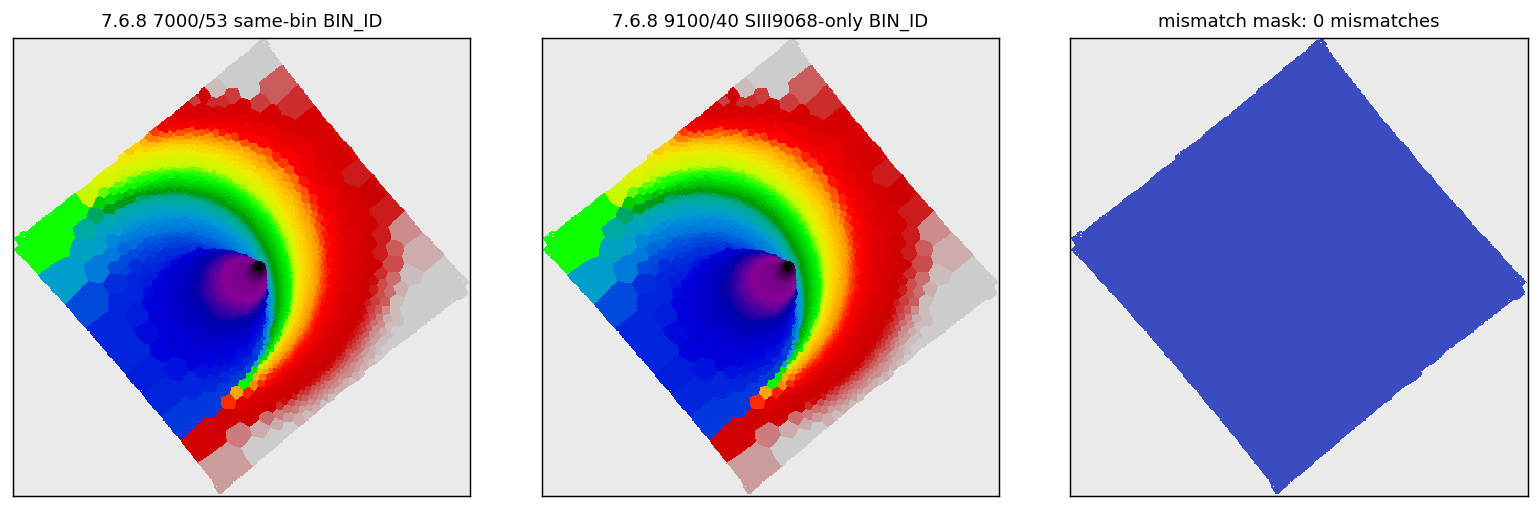

In [3]:
OIII_EXTENSIONS = [
    'BIN_ID',
    f'{OIII_LINE}_FLUX',
    f'{OIII_LINE}_FLUX_ERR',
    f'{OIII_LINE}_VEL',
    f'{OIII_LINE}_VEL_ERR',
    f'{OIII_LINE}_SIGMA',
    f'{OIII_LINE}_SIGMA_ERR',
    f'{OIII_LINE}_SIGMA_CORR',
]


def fits_extnames(path):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        return [hdu.name for hdu in hdul]


def read_map(path, extname):
    with fits.open(path, memmap=False, ignore_missing_end=True) as hdul:
        arr = np.array(hdul[extname].data, dtype=float)
    arr[~np.isfinite(arr)] = np.nan
    return arr


availability_rows = []
for run_key in RUN_ORDER:
    extnames = set(fits_extnames(RUNS[run_key]['gas_path']))
    missing = [ext for ext in OIII_EXTENSIONS if ext not in extnames]
    availability_rows.append({
        'run_key': run_key,
        'n_extensions': len(extnames),
        'missing_oiii_extensions': ', '.join(missing),
        'all_oiii_available': len(missing) == 0,
    })
availability = pd.DataFrame(availability_rows)
display(availability)
assert availability['all_oiii_available'].all(), 'Required OIII extensions are missing.'

maps = {
    extname: {run_key: read_map(RUNS[run_key]['gas_path'], extname) for run_key in RUN_ORDER}
    for extname in OIII_EXTENSIONS
}

baseline_bins = maps['BIN_ID'][BASELINE_RUN]
compare_bins = maps['BIN_ID'][COMPARE_RUN]
same_shape = baseline_bins.shape == compare_bins.shape
exact_equal = bool(same_shape and np.array_equal(baseline_bins, compare_bins, equal_nan=True))
finite_both = np.isfinite(baseline_bins) & np.isfinite(compare_bins)
n_mismatch = int(np.count_nonzero(finite_both & (baseline_bins != compare_bins))) if same_shape else np.nan
binning_check = pd.DataFrame([{
    'same_shape': same_shape,
    'exact_equal_including_nan': exact_equal,
    'finite_pixels_in_both': int(finite_both.sum()) if same_shape else np.nan,
    'n_finite_mismatches': n_mismatch,
    'n_unique_bins': int(np.unique(baseline_bins[np.isfinite(baseline_bins) & (baseline_bins >= 0)]).size),
}])
display(binning_check)
assert exact_equal, 'The two runs do not have identical BIN_ID maps.'

fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.8), constrained_layout=True)
cmap_bins = plt.get_cmap('nipy_spectral').copy()
cmap_bins.set_bad('0.92')
cmap_mismatch = plt.get_cmap('coolwarm').copy()
cmap_mismatch.set_bad('0.92')
for ax, arr, title in [
    (axes[0], baseline_bins, f'{RUNS[BASELINE_RUN]["plot_label"]} BIN_ID'),
    (axes[1], compare_bins, f'{RUNS[COMPARE_RUN]["plot_label"]} BIN_ID'),
]:
    ax.imshow(np.ma.masked_invalid(arr), origin='lower', cmap=cmap_bins, interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
mismatch = np.full(baseline_bins.shape, np.nan, dtype=float)
mismatch[finite_both] = baseline_bins[finite_both] != compare_bins[finite_both]
axes[2].imshow(mismatch, origin='lower', cmap=cmap_mismatch, vmin=0, vmax=1, interpolation='nearest')
axes[2].set_title(f'mismatch mask: {n_mismatch} mismatches', fontsize=10)
axes[2].set_xticks([])
axes[2].set_yticks([])
plt.show()


## Build One-Row-Per-Bin OIII Table

The GAS maps are image-shaped, so this table collapses each `BIN_ID` to one median row. It keeps OIII flux/error, velocity, sigma, formal errors, residuals, ratios, and bin-center coordinates.


In [4]:
def line_fluxerr(run_key):
    flux = maps[f'{OIII_LINE}_FLUX'][run_key]
    err = maps[f'{OIII_LINE}_FLUX_ERR'][run_key]
    ratio = np.full(flux.shape, np.nan, dtype=float)
    valid = np.isfinite(flux) & np.isfinite(err) & (err > 0)
    ratio[valid] = flux[valid] / err[valid]
    return ratio


def robust_sigma(values):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return float(0.5 * (np.nanpercentile(values, 84) - np.nanpercentile(values, 16)))


fluxerr_maps = {run_key: line_fluxerr(run_key) for run_key in RUN_ORDER}
rows, cols = np.indices(baseline_bins.shape)
valid_bin_pixels = np.isfinite(baseline_bins) & (baseline_bins >= 0)

pixel_table = pd.DataFrame({
    'bin_id': baseline_bins[valid_bin_pixels].astype(int),
    'row': rows[valid_bin_pixels].astype(float),
    'col': cols[valid_bin_pixels].astype(float),
})
for run_key in RUN_ORDER:
    prefix = 'ref' if run_key == BASELINE_RUN else 'cmp'
    pixel_table[f'{prefix}_flux'] = maps[f'{OIII_LINE}_FLUX'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_fluxerr'] = fluxerr_maps[run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_vel'] = maps[f'{OIII_LINE}_VEL'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_vel_err'] = maps[f'{OIII_LINE}_VEL_ERR'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_sigma'] = maps[f'{OIII_LINE}_SIGMA'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_sigma_err'] = maps[f'{OIII_LINE}_SIGMA_ERR'][run_key][valid_bin_pixels]
    pixel_table[f'{prefix}_sigma_corr'] = maps[f'{OIII_LINE}_SIGMA_CORR'][run_key][valid_bin_pixels]

agg = {col: 'median' for col in pixel_table.columns if col != 'bin_id'}
agg['row'] = 'median'
agg['col'] = 'median'
bin_table = pixel_table.groupby('bin_id', as_index=False).agg(agg)
bin_table['n_spaxels'] = pixel_table.groupby('bin_id').size().to_numpy()

bin_table['both_fluxerr_min'] = bin_table[['ref_fluxerr', 'cmp_fluxerr']].min(axis=1)
bin_table['delta_vel'] = bin_table['cmp_vel'] - bin_table['ref_vel']
bin_table['abs_delta_vel'] = np.abs(bin_table['delta_vel'])
bin_table['delta_sigma'] = bin_table['cmp_sigma'] - bin_table['ref_sigma']
bin_table['abs_delta_sigma'] = np.abs(bin_table['delta_sigma'])
bin_table['sigma_ratio'] = bin_table['cmp_sigma'] / bin_table['ref_sigma']
bin_table.loc[~np.isfinite(bin_table['sigma_ratio']) | (bin_table['sigma_ratio'] <= 0), 'sigma_ratio'] = np.nan
bin_table['log10_sigma_ratio'] = np.log10(bin_table['sigma_ratio'])
bin_table['abs_log10_sigma_ratio'] = np.abs(bin_table['log10_sigma_ratio'])

vel_err_quad = np.sqrt(bin_table['ref_vel_err']**2 + bin_table['cmp_vel_err']**2)
sigma_err_quad = np.sqrt(bin_table['ref_sigma_err']**2 + bin_table['cmp_sigma_err']**2)
bin_table['delta_vel_over_formal_err'] = bin_table['delta_vel'] / vel_err_quad.replace(0, np.nan)
bin_table['delta_sigma_over_formal_err'] = bin_table['delta_sigma'] / sigma_err_quad.replace(0, np.nan)
bin_table['abs_delta_vel_over_formal_err'] = np.abs(bin_table['delta_vel_over_formal_err'])
bin_table['abs_delta_sigma_over_formal_err'] = np.abs(bin_table['delta_sigma_over_formal_err'])

summary_cols = [
    'bin_id', 'row', 'col', 'n_spaxels', 'ref_fluxerr', 'cmp_fluxerr', 'both_fluxerr_min',
    'ref_vel', 'cmp_vel', 'delta_vel', 'abs_delta_vel', 'ref_sigma', 'cmp_sigma',
    'delta_sigma', 'abs_delta_sigma', 'sigma_ratio', 'log10_sigma_ratio',
    'ref_vel_err', 'cmp_vel_err', 'ref_sigma_err', 'cmp_sigma_err',
]
display(bin_table[summary_cols].head())
print(f'One row per OIII bin: {len(bin_table):,}')


,bin_id,row,col,n_spaxels,ref_fluxerr,cmp_fluxerr,both_fluxerr_min,ref_vel,cmp_vel,delta_vel,abs_delta_vel,ref_sigma,cmp_sigma,delta_sigma,abs_delta_sigma,sigma_ratio,log10_sigma_ratio,ref_vel_err,cmp_vel_err,ref_sigma_err,cmp_sigma_err
0,0,219.0,233.0,1,10.379920,10.233440,10.233440,24.346302,26.176855,1.830553,1.830553,82.276645,78.421974,-3.854671,3.854671,0.953150,-0.020839,11.200067,10.847820,17.990619,18.910972
1,1,219.0,234.0,1,8.815816,7.797384,7.797384,1.666905,-57.811898,-59.478803,59.478803,93.455133,197.837490,104.382357,104.382357,2.116925,0.325705,15.391011,25.819594,21.088208,26.924014
2,2,218.0,234.0,1,9.841161,6.622632,6.622632,14.226059,-21.729377,-35.955435,35.955435,64.616388,172.821422,108.205035,108.205035,2.674576,0.427255,9.384720,20.474598,66.950492,20.647886
3,3,218.0,233.0,1,11.095179,10.171072,10.171072,13.638244,-4.392683,-18.030927,18.030927,97.317618,167.243805,69.926187,69.926187,1.718536,0.235159,12.432965,18.092885,16.768479,18.350902
4,4,218.0,235.0,1,7.866447,6.242450,6.242450,63.026453,17.821804,-45.204649,45.204649,101.964187,183.916626,81.952439,81.952439,1.803737,0.256173,18.397380,25.249229,24.542005,26.203133


One row per OIII bin: 4,032


## OIII S/N Population And Outlier Ranking

The high-S/N working sample defaults to bins with `Flux/Err > 20` in both runs. The selected-bin list is the union of the largest `abs(log10 sigma ratio)` bins and the largest `abs(delta velocity)` bins in that high-S/N sample.


In [5]:
population_rows = []
for cut in SNR_CUTS:
    subset = bin_table[bin_table['both_fluxerr_min'] > cut]
    population_rows.append({
        'fluxerr_cut_in_both_runs': f'>{cut:g}',
        'n_bins': int(len(subset)),
        'fraction_of_bins': float(len(subset) / len(bin_table)),
        'median_ref_fluxerr': float(np.nanmedian(subset['ref_fluxerr'])) if len(subset) else np.nan,
        'median_cmp_fluxerr': float(np.nanmedian(subset['cmp_fluxerr'])) if len(subset) else np.nan,
        'median_delta_vel': float(np.nanmedian(subset['delta_vel'])) if len(subset) else np.nan,
        'robust_sigma_delta_vel': robust_sigma(subset['delta_vel']) if len(subset) else np.nan,
        'median_delta_sigma': float(np.nanmedian(subset['delta_sigma'])) if len(subset) else np.nan,
        'robust_sigma_delta_sigma': robust_sigma(subset['delta_sigma']) if len(subset) else np.nan,
        'median_sigma_ratio': float(np.nanmedian(subset['sigma_ratio'])) if len(subset) else np.nan,
        'robust_sigma_log10_ratio': robust_sigma(subset['log10_sigma_ratio']) if len(subset) else np.nan,
    })
population_summary = pd.DataFrame(population_rows)
display(population_summary)

high_snr = bin_table[
    (bin_table['both_fluxerr_min'] > HIGH_SNR_CUT)
    & np.isfinite(bin_table['delta_vel'])
    & np.isfinite(bin_table['log10_sigma_ratio'])
].copy()

sigma_outliers = high_snr.sort_values('abs_log10_sigma_ratio', ascending=False).head(N_TOP_SIGMA).copy()
sigma_outliers['candidate_reason'] = 'large sigma ratio'
vel_outliers = high_snr.sort_values('abs_delta_vel', ascending=False).head(N_TOP_VEL).copy()
vel_outliers['candidate_reason'] = 'large velocity difference'
candidates = pd.concat([sigma_outliers, vel_outliers], ignore_index=True)
reason_by_bin = candidates.groupby('bin_id')['candidate_reason'].apply(lambda values: '; '.join(sorted(set(values))))
selected_bins = (
    high_snr[high_snr['bin_id'].isin(reason_by_bin.index)]
    .copy()
    .assign(selection_reason=lambda df: df['bin_id'].map(reason_by_bin))
    .sort_values(['abs_log10_sigma_ratio', 'abs_delta_vel'], ascending=False)
)

if len(selected_bins) < N_SPECTRA_TO_PLOT:
    filler = (
        high_snr[~high_snr['bin_id'].isin(selected_bins['bin_id'])]
        .copy()
        .assign(selection_reason='next largest combined deviation')
        .sort_values(['abs_log10_sigma_ratio', 'abs_delta_vel'], ascending=False)
        .head(N_SPECTRA_TO_PLOT - len(selected_bins))
    )
    selected_bins = pd.concat([selected_bins, filler], ignore_index=True)

selected_bins = selected_bins.head(N_SPECTRA_TO_PLOT).reset_index(drop=True)

selected_cols = [
    'selection_reason', 'bin_id', 'row', 'col', 'n_spaxels', 'both_fluxerr_min',
    'ref_fluxerr', 'cmp_fluxerr', 'delta_vel', 'abs_delta_vel',
    'delta_sigma', 'abs_delta_sigma', 'sigma_ratio', 'log10_sigma_ratio',
    'ref_vel', 'cmp_vel', 'ref_sigma', 'cmp_sigma',
    'abs_delta_vel_over_formal_err', 'abs_delta_sigma_over_formal_err',
]
display(selected_bins[selected_cols])

print(f'High-S/N OIII bins with Flux/Err > {HIGH_SNR_CUT:g} in both runs: {len(high_snr):,}')
print(f'Selected most-deviated bins for visual inspection: {len(selected_bins):,}')


,fluxerr_cut_in_both_runs,n_bins,fraction_of_bins,median_ref_fluxerr,median_cmp_fluxerr,median_delta_vel,robust_sigma_delta_vel,median_delta_sigma,robust_sigma_delta_sigma,median_sigma_ratio,robust_sigma_log10_ratio
0,>0,3998,0.991567,9.055547,8.676317,-1.050245,34.207434,2.402653,28.634670,1.030147,0.102962
1,>3,3801,0.942708,9.274445,8.900475,-0.965510,30.952768,2.030304,28.104579,1.024970,0.101372
2,>5,3377,0.837550,9.699088,9.390608,-0.898516,26.633181,2.061725,26.822954,1.025582,0.096744
3,>10,1368,0.339286,12.398687,12.292069,-0.979735,15.939968,3.241239,20.149015,1.037887,0.071689
4,>20,59,0.014633,24.016560,24.505845,-0.454055,3.266177,6.609597,8.876605,1.067463,0.036030
5,>50,1,0.000248,52.031861,52.645132,-1.317779,0.000000,1.990617,0.000000,1.022579,0.000000


,selection_reason,bin_id,row,col,n_spaxels,both_fluxerr_min,ref_fluxerr,cmp_fluxerr,delta_vel,abs_delta_vel,delta_sigma,abs_delta_sigma,sigma_ratio,log10_sigma_ratio,ref_vel,cmp_vel,ref_sigma,cmp_sigma,abs_delta_vel_over_formal_err,abs_delta_sigma_over_formal_err
0,large sigma ratio,3277,200.0,292.0,8,20.713541,20.713541,20.862802,-3.389460,3.389460,49.706837,49.706837,1.484373,0.171543,-21.449641,-24.839101,102.621033,152.327870,0.312632,3.866534
1,large sigma ratio,908,87.0,187.0,451,22.660587,22.660587,23.437506,-0.036518,0.036518,47.659405,47.659405,1.402275,0.146833,4.913349,4.876831,118.474543,166.133948,0.003167,3.917706
2,large sigma ratio; large velocity difference,2369,304.0,162.0,16,20.821350,22.320831,20.821350,23.579295,23.579295,-23.408217,23.408217,0.742492,-0.129308,100.166363,123.745658,90.903007,67.494790,3.891465,2.565378
3,large sigma ratio,2310,229.5,256.5,4,20.760708,20.820768,20.760708,-6.302466,6.302466,31.306369,31.306369,1.325341,0.122328,-2.560149,-8.862614,96.226285,127.532654,0.666246,2.677249
4,large sigma ratio; large velocity difference,2358,297.5,192.0,10,20.309591,21.097449,20.309591,16.293514,16.293514,-23.506958,23.506958,0.756585,-0.121142,104.934936,121.228451,96.571649,73.064691,2.302076,2.355423
5,large sigma ratio,347,195.0,213.0,11,26.392405,26.576036,26.392405,-1.196873,1.196873,-26.054732,26.054732,0.762047,-0.118018,29.486577,28.289704,109.495352,83.440621,0.194983,3.406515
6,large velocity difference,2254,296.0,190.0,9,20.891518,21.201866,20.891518,11.231745,11.231745,-19.362926,19.362926,0.806705,-0.093285,107.904101,119.135846,100.172819,80.809893,1.494712,1.961078
7,large velocity difference,2349,298.5,188.0,10,21.998273,22.075691,21.998273,21.512835,21.512835,-8.962347,8.962347,0.893264,-0.049020,104.666720,126.179555,83.967301,75.004954,3.593132,0.965183
8,large velocity difference,381,193.0,211.0,11,34.976673,35.873955,34.976673,-14.965082,14.965082,-12.719783,12.719783,0.893873,-0.048724,59.726059,44.760977,119.854143,107.134360,2.687243,1.929199
9,large velocity difference,3354,164.0,284.0,9,21.685736,22.233704,21.685736,-14.742684,14.742684,4.254787,4.254787,1.046314,0.019662,-50.901795,-65.644479,91.868532,96.123319,1.872902,0.380338


High-S/N OIII bins with Flux/Err > 20 in both runs: 59
Selected most-deviated bins for visual inspection: 10


## Quick Context: Previous 9100/40 Reruns Versus SIII9068-Only 9100/40

The rest of this notebook uses the `SIII9068-only` run as the comparison run. This small table keeps the old full-line, plain used-line, ArIII/no-SIII, and SIII-tied `9100/40` results nearby as context, using the same 7000/53 same-bin reference and the same one-row-per-bin OIII summary logic. The main comparison remains the current run versus the reference; the extra rows are only a compact check against the recent reruns.


In [6]:
CONTEXT_COMPARISON_RUNS = [
    {
        'key': 'full_9100_40_previous',
        'plot_label': '7.6.8 9100/40 full-line',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
    },
    {
        'key': 'plain_use_9100_40_previous',
        'plot_label': '7.6.8 9100/40 plain used-lines',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_use' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
    },
    {
        'key': 'ariii_no_siii_9100_40_previous',
        'plot_label': '7.6.8 9100/40 ArIII/no-SIII',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_use_ArIII_noSIII' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
    },
    {
        'key': 'use_trick_9100_40_previous',
        'plot_label': '7.6.8 9100/40 use-trick',
        'gas_path': root / 'v3tk_v7.6.8_VELSCALE40_use_trick' / GALAXY / f'{GALAXY}_gas_bin_maps.fits',
    },
]


def one_row_per_bin_for_comparison(compare_path):
    compare_maps = {
        ext: read_map(compare_path, 'BIN_ID' if ext == 'BIN_ID' else f'{OIII_LINE}_{ext}')
        for ext in ['BIN_ID', 'FLUX', 'FLUX_ERR', 'VEL', 'VEL_ERR', 'SIGMA', 'SIGMA_ERR']
    }
    compare_fluxerr = np.full(compare_maps['FLUX'].shape, np.nan, dtype=float)
    ok = np.isfinite(compare_maps['FLUX']) & np.isfinite(compare_maps['FLUX_ERR']) & (compare_maps['FLUX_ERR'] > 0)
    compare_fluxerr[ok] = compare_maps['FLUX'][ok] / compare_maps['FLUX_ERR'][ok]

    rows, cols = np.indices(baseline_bins.shape)
    valid = np.isfinite(baseline_bins) & (baseline_bins >= 0)
    table = pd.DataFrame({
        'bin_id': baseline_bins[valid].astype(int),
        'row': rows[valid].astype(float),
        'col': cols[valid].astype(float),
        'ref_fluxerr': fluxerr_maps[BASELINE_RUN][valid],
        'cmp_fluxerr': compare_fluxerr[valid],
        'ref_vel': maps[f'{OIII_LINE}_VEL'][BASELINE_RUN][valid],
        'cmp_vel': compare_maps['VEL'][valid],
        'ref_sigma': maps[f'{OIII_LINE}_SIGMA'][BASELINE_RUN][valid],
        'cmp_sigma': compare_maps['SIGMA'][valid],
    })
    out = table.groupby('bin_id', as_index=False).median(numeric_only=True)
    out['both_fluxerr_min'] = out[['ref_fluxerr', 'cmp_fluxerr']].min(axis=1)
    out['delta_vel'] = out['cmp_vel'] - out['ref_vel']
    out['delta_sigma'] = out['cmp_sigma'] - out['ref_sigma']
    out['sigma_ratio'] = out['cmp_sigma'] / out['ref_sigma']
    out.loc[~np.isfinite(out['sigma_ratio']) | (out['sigma_ratio'] <= 0), 'sigma_ratio'] = np.nan
    out['log10_sigma_ratio'] = np.log10(out['sigma_ratio'])
    return out


comparison_tables = {
    RUNS[COMPARE_RUN]['plot_label']: bin_table,
}
for run in CONTEXT_COMPARISON_RUNS:
    if run['gas_path'].exists():
        comparison_tables[run['plot_label']] = one_row_per_bin_for_comparison(run['gas_path'])

context_rows = []
for label, table in comparison_tables.items():
    for cut in [10, 20, 50]:
        subset = table[
            (table['both_fluxerr_min'] > cut)
            & np.isfinite(table['delta_vel'])
            & np.isfinite(table['delta_sigma'])
            & np.isfinite(table['log10_sigma_ratio'])
        ]
        context_rows.append({
            'comparison_run': label,
            'fluxerr_cut_in_both_runs': f'>{cut:g}',
            'n_bins': int(len(subset)),
            'median_delta_vel': float(np.nanmedian(subset['delta_vel'])) if len(subset) else np.nan,
            'robust_sigma_delta_vel': robust_sigma(subset['delta_vel']) if len(subset) else np.nan,
            'median_delta_sigma': float(np.nanmedian(subset['delta_sigma'])) if len(subset) else np.nan,
            'robust_sigma_delta_sigma': robust_sigma(subset['delta_sigma']) if len(subset) else np.nan,
            'median_sigma_ratio': float(np.nanmedian(subset['sigma_ratio'])) if len(subset) else np.nan,
            'robust_sigma_log10_ratio': robust_sigma(subset['log10_sigma_ratio']) if len(subset) else np.nan,
        })
SIII9068_only_context = pd.DataFrame(context_rows)
display(SIII9068_only_context)


,comparison_run,fluxerr_cut_in_both_runs,n_bins,median_delta_vel,robust_sigma_delta_vel,median_delta_sigma,robust_sigma_delta_sigma,median_sigma_ratio,robust_sigma_log10_ratio
0,7.6.8 9100/40 SIII9068-only,>10,1368,-0.979735,15.939968,3.241239,20.149015,1.037887,0.071689
1,7.6.8 9100/40 SIII9068-only,>20,59,-0.454055,3.266177,6.609597,8.876605,1.067463,0.036030
2,7.6.8 9100/40 SIII9068-only,>50,1,-1.317779,0.000000,1.990617,0.000000,1.022579,0.000000
3,7.6.8 9100/40 full-line,>10,1361,-1.136025,15.589451,2.804637,19.543203,1.034372,0.071268
4,7.6.8 9100/40 full-line,>20,59,-0.724511,3.290024,6.508748,7.818408,1.062135,0.034192
5,7.6.8 9100/40 full-line,>50,1,-1.312984,0.000000,2.036835,0.000000,1.023103,0.000000
6,7.6.8 9100/40 plain used-lines,>10,1369,-0.935322,15.497315,3.225889,19.913738,1.038138,0.072733
7,7.6.8 9100/40 plain used-lines,>20,59,-0.479328,3.323788,6.476915,8.120248,1.065027,0.033772
8,7.6.8 9100/40 plain used-lines,>50,1,-1.316244,0.000000,1.988482,0.000000,1.022555,0.000000
9,7.6.8 9100/40 ArIII/no-SIII,>10,1460,-0.922770,1.938479,-1.211237,3.609339,0.985971,0.017112


## OIII Maps With Selected Bins

These maps show where the selected suspicious bins sit relative to OIII signal-to-noise, velocity residuals, and sigma-ratio structure.


### How The Map Diagnostic Figure Is Built

The next cell plots image-space OIII diagnostics from the two already-loaded GAS map files. The background maps use all finite OIII map pixels, not only the high-S/N subset, so you can see where the suspicious bins sit in the full galaxy context.

The plotted quantities are:

- `Flux/Err` in the `7000/53 same-bin` run.
- `Flux/Err` in the `9100/40` run.
- the minimum of the two `Flux/Err` maps, which shows where both runs have usable OIII signal.
- `delta VEL = VEL_9100/40 - VEL_7000/53_samebin`.
- `delta SIGMA = SIGMA_9100/40 - SIGMA_7000/53_samebin`.
- `log10(SIGMA_9100/40 / SIGMA_7000/53_samebin)`.

The black circles are the `selected_bins` from the previous ranking cell. Their positions are the median row/column of all spaxels in that `BIN_ID`, and the text labels are the bin IDs. Color limits are robust: percentile limits for Flux/Err maps, and symmetric percentile limits for residual/ratio maps, so a few extreme pixels do not flatten the useful contrast.


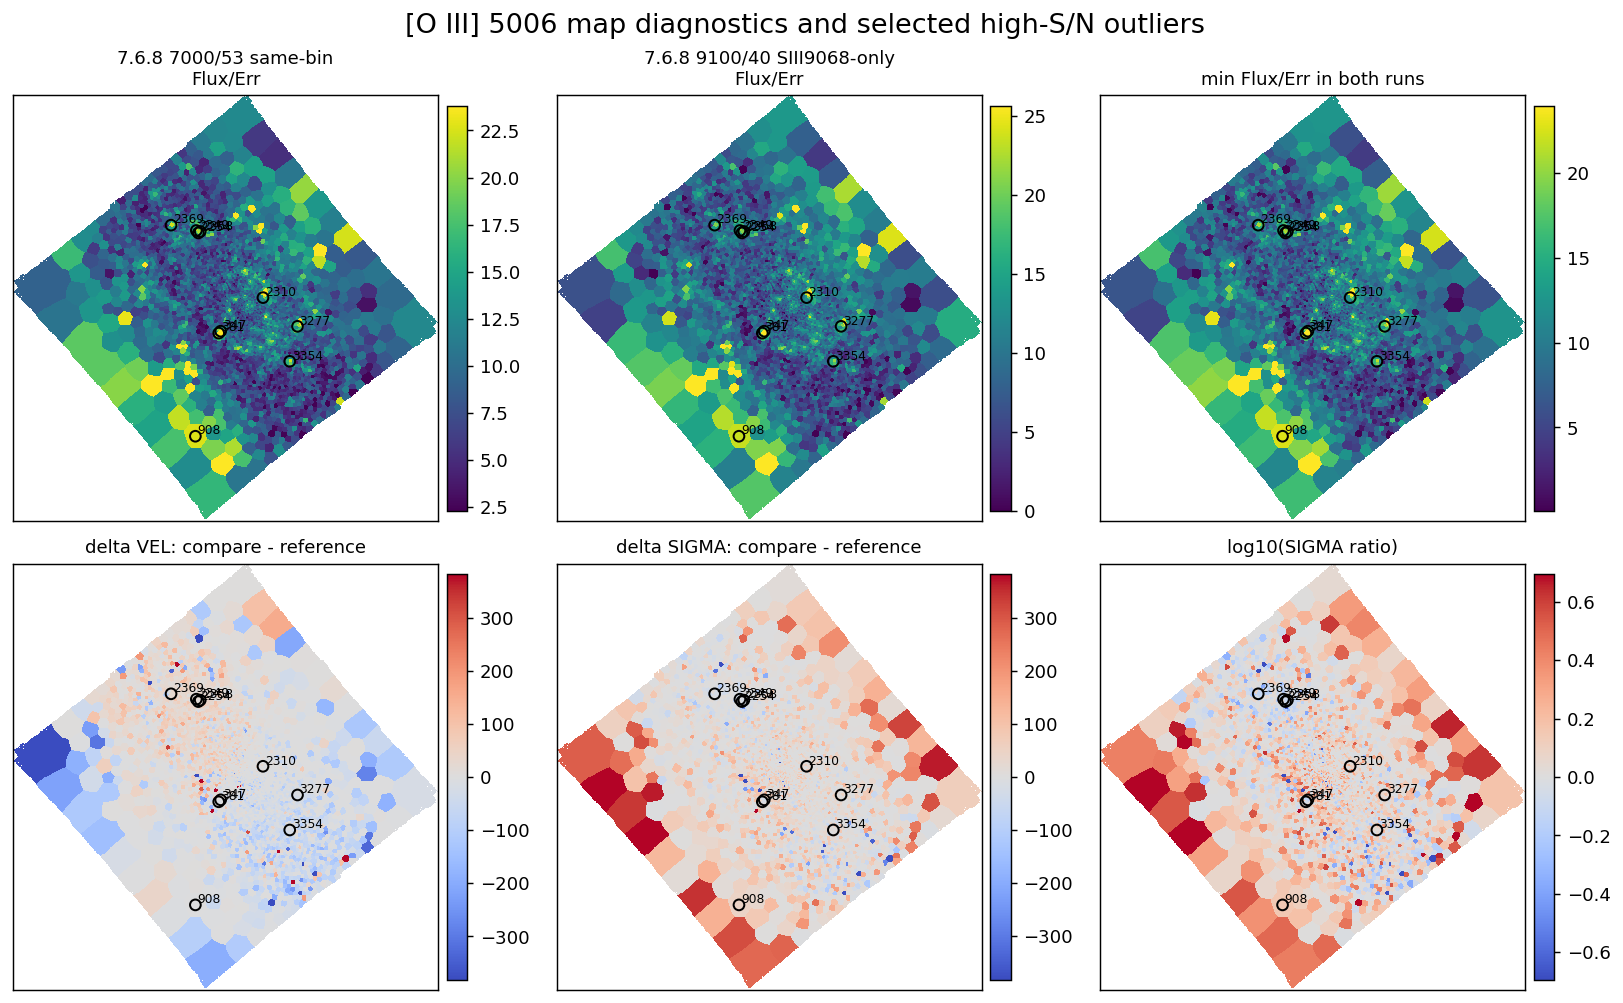

In [7]:
def robust_limits(values, p=(2, 98), pad_fraction=0.06, fallback=(-1, 1)):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return fallback
    lo, hi = np.nanpercentile(values, p)
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        center = np.nanmedian(values)
        spread = np.nanstd(values)
        spread = spread if np.isfinite(spread) and spread > 0 else 1.0
        lo, hi = center - spread, center + spread
    pad = pad_fraction * (hi - lo)
    return float(lo - pad), float(hi + pad)


def symmetric_limit(values, percentile=98, fallback=1.0):
    values = np.abs(np.asarray(values)[np.isfinite(values)])
    if values.size == 0:
        return fallback
    limit = np.nanpercentile(values, percentile)
    return float(limit if np.isfinite(limit) and limit > 0 else fallback)


delta_vel_map = maps[f'{OIII_LINE}_VEL'][COMPARE_RUN] - maps[f'{OIII_LINE}_VEL'][BASELINE_RUN]
delta_sigma_map = maps[f'{OIII_LINE}_SIGMA'][COMPARE_RUN] - maps[f'{OIII_LINE}_SIGMA'][BASELINE_RUN]
sigma_ratio_map = maps[f'{OIII_LINE}_SIGMA'][COMPARE_RUN] / maps[f'{OIII_LINE}_SIGMA'][BASELINE_RUN]
sigma_ratio_map[~np.isfinite(sigma_ratio_map) | (sigma_ratio_map <= 0)] = np.nan
log_sigma_ratio_map = np.log10(sigma_ratio_map)

fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.6), constrained_layout=True)
fig.suptitle(f'{OIII_LABEL} map diagnostics and selected high-S/N outliers', fontsize=15)

panels = [
    (axes[0, 0], fluxerr_maps[BASELINE_RUN], f'{RUNS[BASELINE_RUN]["plot_label"]}\nFlux/Err', 'viridis', None),
    (axes[0, 1], fluxerr_maps[COMPARE_RUN], f'{RUNS[COMPARE_RUN]["plot_label"]}\nFlux/Err', 'viridis', None),
    (axes[0, 2], np.minimum(fluxerr_maps[BASELINE_RUN], fluxerr_maps[COMPARE_RUN]), 'min Flux/Err in both runs', 'viridis', None),
    (axes[1, 0], delta_vel_map, 'delta VEL: compare - reference', 'coolwarm', symmetric_limit(delta_vel_map, 98, 25)),
    (axes[1, 1], delta_sigma_map, 'delta SIGMA: compare - reference', 'coolwarm', symmetric_limit(delta_sigma_map, 98, 25)),
    (axes[1, 2], log_sigma_ratio_map, 'log10(SIGMA ratio)', 'coolwarm', symmetric_limit(log_sigma_ratio_map, 98, 0.3)),
]

for ax, arr, title, cmap, lim in panels:
    plot_arr = np.ma.masked_invalid(arr)
    if lim is None:
        vmin, vmax = robust_limits(arr, p=(2, 98), fallback=(0, 20))
        im = ax.imshow(plot_arr, origin='lower', cmap=cmap, vmin=max(vmin, 0), vmax=vmax, interpolation='nearest')
    else:
        im = ax.imshow(plot_arr, origin='lower', cmap=cmap, vmin=-lim, vmax=lim, interpolation='nearest')
    ax.scatter(selected_bins['col'], selected_bins['row'], s=35, facecolors='none', edgecolors='black', linewidths=1.1)
    for _, row in selected_bins.iterrows():
        ax.text(row['col'] + 2, row['row'] + 2, str(int(row['bin_id'])), fontsize=6.8, color='black')
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)

plt.show()


## OIII Pairwise And Ratio Views

Selected bins are highlighted on the same OIII-only pairwise views used for ranking.


### How The Pairwise/Ratio Plot Data Is Selected

The next cell switches from image pixels to the one-row-per-bin table. The gray point cloud is `high_snr`, defined in the ranking cell as bins with:

`min(Flux/Err_7000/53_samebin, Flux/Err_9100/40) > HIGH_SNR_CUT`

where `HIGH_SNR_CUT = 20` by default. This keeps the pairwise views focused on bins where OIII is at least plausibly measured in both runs.

The highlighted/labeled points are the same `selected_bins`: the union of the largest sigma-ratio outliers and the largest velocity-difference outliers. The four panels show velocity agreement, velocity residuals, sigma agreement in log-log space, and the sigma ratio as `log10(SIGMA_9100/40 / SIGMA_7000/53_samebin)`.


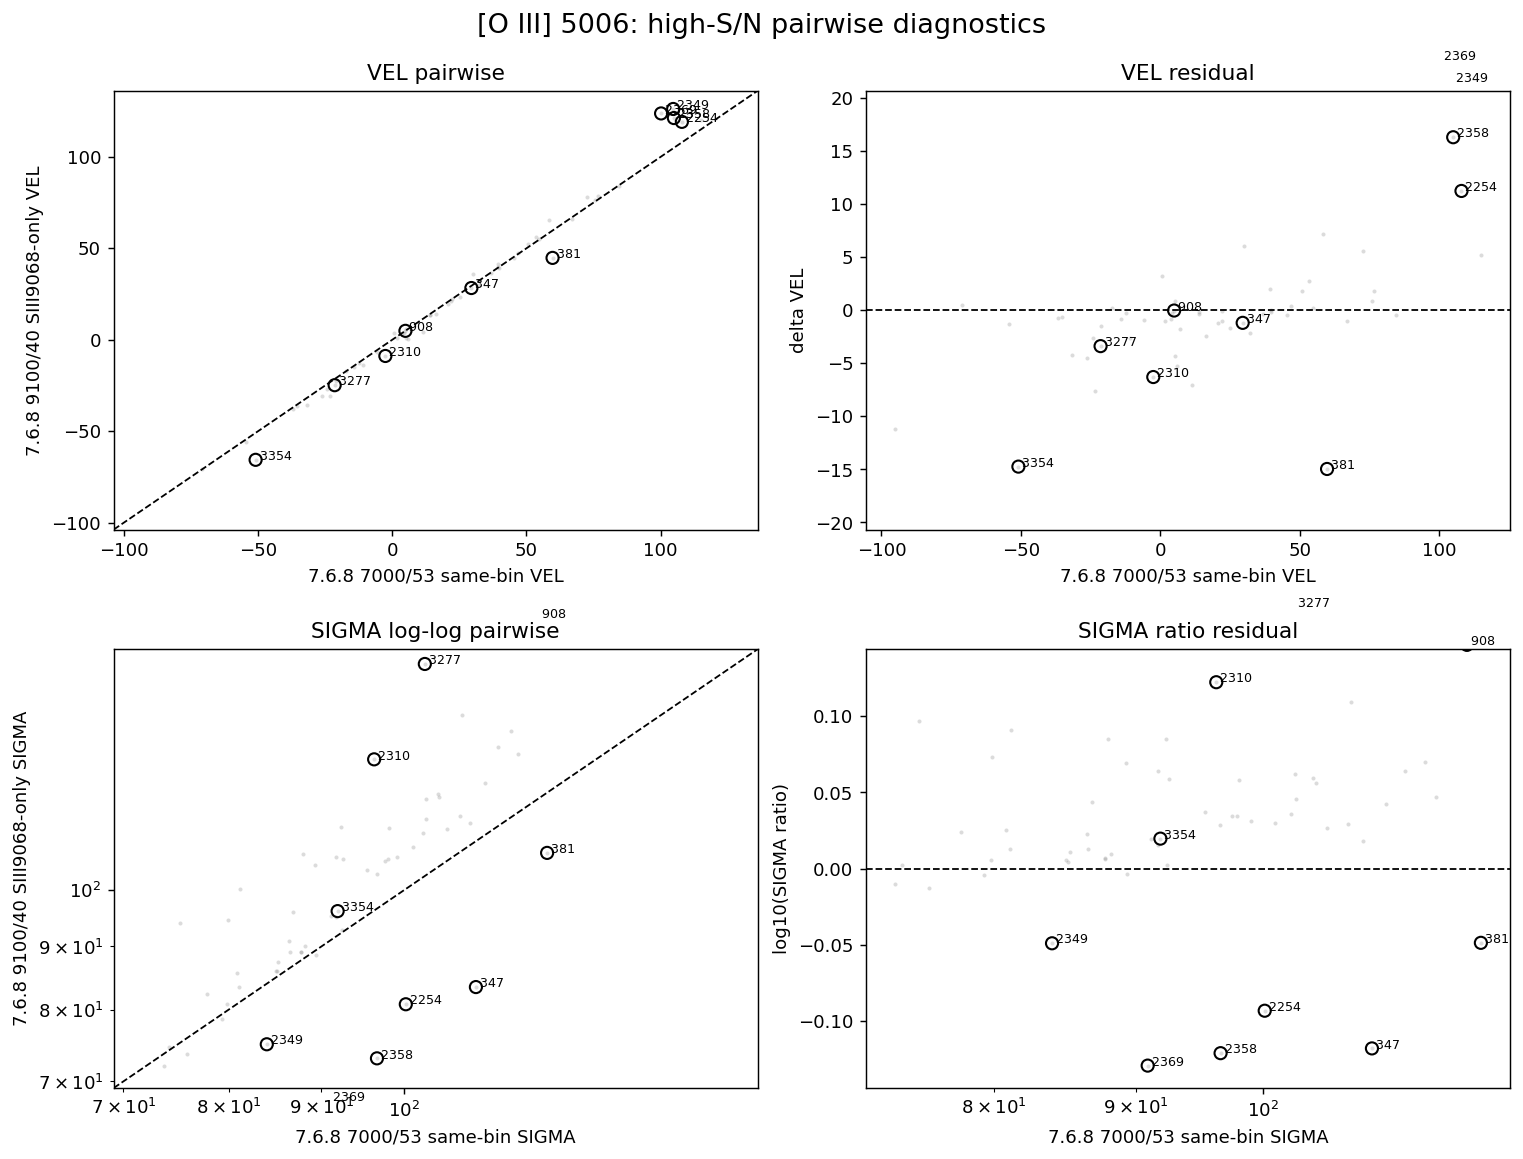

In [8]:
def scatter_selected(ax, x_col, y_col, color='black'):
    ax.scatter(selected_bins[x_col], selected_bins[y_col], s=45, facecolors='none', edgecolors=color, linewidths=1.15, zorder=5)
    for _, row in selected_bins.iterrows():
        ax.text(row[x_col], row[y_col], f' {int(row["bin_id"])}', fontsize=7, color=color, zorder=6)


fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), constrained_layout=True)
fig.suptitle(f'{OIII_LABEL}: high-S/N pairwise diagnostics', fontsize=15)

plot_sample = high_snr.copy()
if len(plot_sample) > 25000:
    plot_sample = plot_sample.sample(25000, random_state=12)

ax = axes[0, 0]
lo, hi = robust_limits(high_snr[['ref_vel', 'cmp_vel']].to_numpy().ravel(), p=(1, 99), fallback=(-150, 150))
ax.scatter(plot_sample['ref_vel'], plot_sample['cmp_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
scatter_selected(ax, 'ref_vel', 'cmp_vel')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} VEL')
ax.set_title('VEL pairwise')

ax = axes[0, 1]
vel_lim = symmetric_limit(high_snr['delta_vel'], 98, 25)
ax.scatter(plot_sample['ref_vel'], plot_sample['delta_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.scatter(selected_bins['ref_vel'], selected_bins['delta_vel'], s=45, facecolors='none', edgecolors='black', linewidths=1.15)
for _, row in selected_bins.iterrows():
    ax.text(row['ref_vel'], row['delta_vel'], f' {int(row["bin_id"])}', fontsize=7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylim(-vel_lim, vel_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel('delta VEL')
ax.set_title('VEL residual')

ax = axes[1, 0]
sigma_values = high_snr[['ref_sigma', 'cmp_sigma']].to_numpy().ravel()
sigma_values = sigma_values[np.isfinite(sigma_values) & (sigma_values > 0)]
slo_log, shi_log = robust_limits(np.log10(sigma_values), p=(1, 99), fallback=(np.log10(30), np.log10(400)))
slo, shi = 10**slo_log, 10**shi_log
ax.scatter(plot_sample['ref_sigma'], plot_sample['cmp_sigma'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([slo, shi], [slo, shi], color='black', linestyle='--', linewidth=1)
scatter_selected(ax, 'ref_sigma', 'cmp_sigma')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(slo, shi)
ax.set_ylim(slo, shi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} SIGMA')
ax.set_title('SIGMA log-log pairwise')

ax = axes[1, 1]
log_lim = symmetric_limit(high_snr['log10_sigma_ratio'], 98, 0.3)
ax.scatter(plot_sample['ref_sigma'], plot_sample['log10_sigma_ratio'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.scatter(selected_bins['ref_sigma'], selected_bins['log10_sigma_ratio'], s=45, facecolors='none', edgecolors='black', linewidths=1.15)
for _, row in selected_bins.iterrows():
    ax.text(row['ref_sigma'], row['log10_sigma_ratio'], f' {int(row["bin_id"])}', fontsize=7)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_ylim(-log_lim, log_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel('log10(SIGMA ratio)')
ax.set_title('SIGMA ratio residual')

plt.show()


## Previous Full-Line Selected Bins Rechecked With SIII9068-Only Run

The section above asks: what are the most suspicious bins after the `SIII9068-only` rerun? This section asks the complementary question: what happened to the exact 10 bins that were suspicious in the previous full-line `9100/40` notebook? Those fixed bin IDs are: `908, 3277, 2369, 347, 2358, 2310, 2254, 381, 2349, 3354`.

The next cells redo the pairwise diagnostics for that fixed old-selection list with the current `9100/40 SIII9068-only` comparison values.


In [9]:
PREVIOUS_FULL_LINE_SELECTED_BINS = [
    ('large sigma ratio', 908),
    ('large sigma ratio', 3277),
    ('large sigma ratio', 2369),
    ('large sigma ratio', 347),
    ('large sigma ratio', 2358),
    ('large sigma ratio', 2310),
    ('large velocity difference', 2254),
    ('large velocity difference', 381),
    ('large velocity difference', 2349),
    ('large velocity difference', 3354),
]

previous_bin_order = [bin_id for _, bin_id in PREVIOUS_FULL_LINE_SELECTED_BINS]
previous_reason_by_bin = {bin_id: reason for reason, bin_id in PREVIOUS_FULL_LINE_SELECTED_BINS}
previous_full_line_selected_bins = (
    bin_table[bin_table['bin_id'].isin(previous_bin_order)]
    .copy()
    .assign(
        previous_full_line_selection_reason=lambda df: df['bin_id'].map(previous_reason_by_bin),
        previous_full_line_order=lambda df: df['bin_id'].map({bin_id: i for i, bin_id in enumerate(previous_bin_order)}),
    )
    .sort_values('previous_full_line_order')
    .reset_index(drop=True)
)

missing_previous_bins = [bin_id for bin_id in previous_bin_order if bin_id not in set(previous_full_line_selected_bins['bin_id'])]
if missing_previous_bins:
    print('Warning: missing previous full-line selected bins in current bin table:', missing_previous_bins)

previous_display_cols = [
    'previous_full_line_selection_reason', 'bin_id', 'row', 'col', 'n_spaxels', 'both_fluxerr_min',
    'ref_fluxerr', 'cmp_fluxerr', 'delta_vel', 'abs_delta_vel',
    'delta_sigma', 'abs_delta_sigma', 'sigma_ratio', 'log10_sigma_ratio',
    'ref_vel', 'cmp_vel', 'ref_sigma', 'cmp_sigma',
]
display(previous_full_line_selected_bins[previous_display_cols])
print(f'Previous full-line selected bins recovered here: {len(previous_full_line_selected_bins):,}')


,previous_full_line_selection_reason,bin_id,row,col,n_spaxels,both_fluxerr_min,ref_fluxerr,cmp_fluxerr,delta_vel,abs_delta_vel,delta_sigma,abs_delta_sigma,sigma_ratio,log10_sigma_ratio,ref_vel,cmp_vel,ref_sigma,cmp_sigma
0,large sigma ratio,908,87.0,187.0,451,22.660587,22.660587,23.437506,-0.036518,0.036518,47.659405,47.659405,1.402275,0.146833,4.913349,4.876831,118.474543,166.133948
1,large sigma ratio,3277,200.0,292.0,8,20.713541,20.713541,20.862802,-3.389460,3.389460,49.706837,49.706837,1.484373,0.171543,-21.449641,-24.839101,102.621033,152.327870
2,large sigma ratio,2369,304.0,162.0,16,20.821350,22.320831,20.821350,23.579295,23.579295,-23.408217,23.408217,0.742492,-0.129308,100.166363,123.745658,90.903007,67.494790
3,large sigma ratio,347,195.0,213.0,11,26.392405,26.576036,26.392405,-1.196873,1.196873,-26.054732,26.054732,0.762047,-0.118018,29.486577,28.289704,109.495352,83.440621
4,large sigma ratio,2358,297.5,192.0,10,20.309591,21.097449,20.309591,16.293514,16.293514,-23.506958,23.506958,0.756585,-0.121142,104.934936,121.228451,96.571649,73.064691
5,large sigma ratio,2310,229.5,256.5,4,20.760708,20.820768,20.760708,-6.302466,6.302466,31.306369,31.306369,1.325341,0.122328,-2.560149,-8.862614,96.226285,127.532654
6,large velocity difference,2254,296.0,190.0,9,20.891518,21.201866,20.891518,11.231745,11.231745,-19.362926,19.362926,0.806705,-0.093285,107.904101,119.135846,100.172819,80.809893
7,large velocity difference,381,193.0,211.0,11,34.976673,35.873955,34.976673,-14.965082,14.965082,-12.719783,12.719783,0.893873,-0.048724,59.726059,44.760977,119.854143,107.134360
8,large velocity difference,2349,298.5,188.0,10,21.998273,22.075691,21.998273,21.512835,21.512835,-8.962347,8.962347,0.893264,-0.049020,104.666720,126.179555,83.967301,75.004954
9,large velocity difference,3354,164.0,284.0,9,21.685736,22.233704,21.685736,-14.742684,14.742684,4.254787,4.254787,1.046314,0.019662,-50.901795,-65.644479,91.868532,96.123319


Previous full-line selected bins recovered here: 10


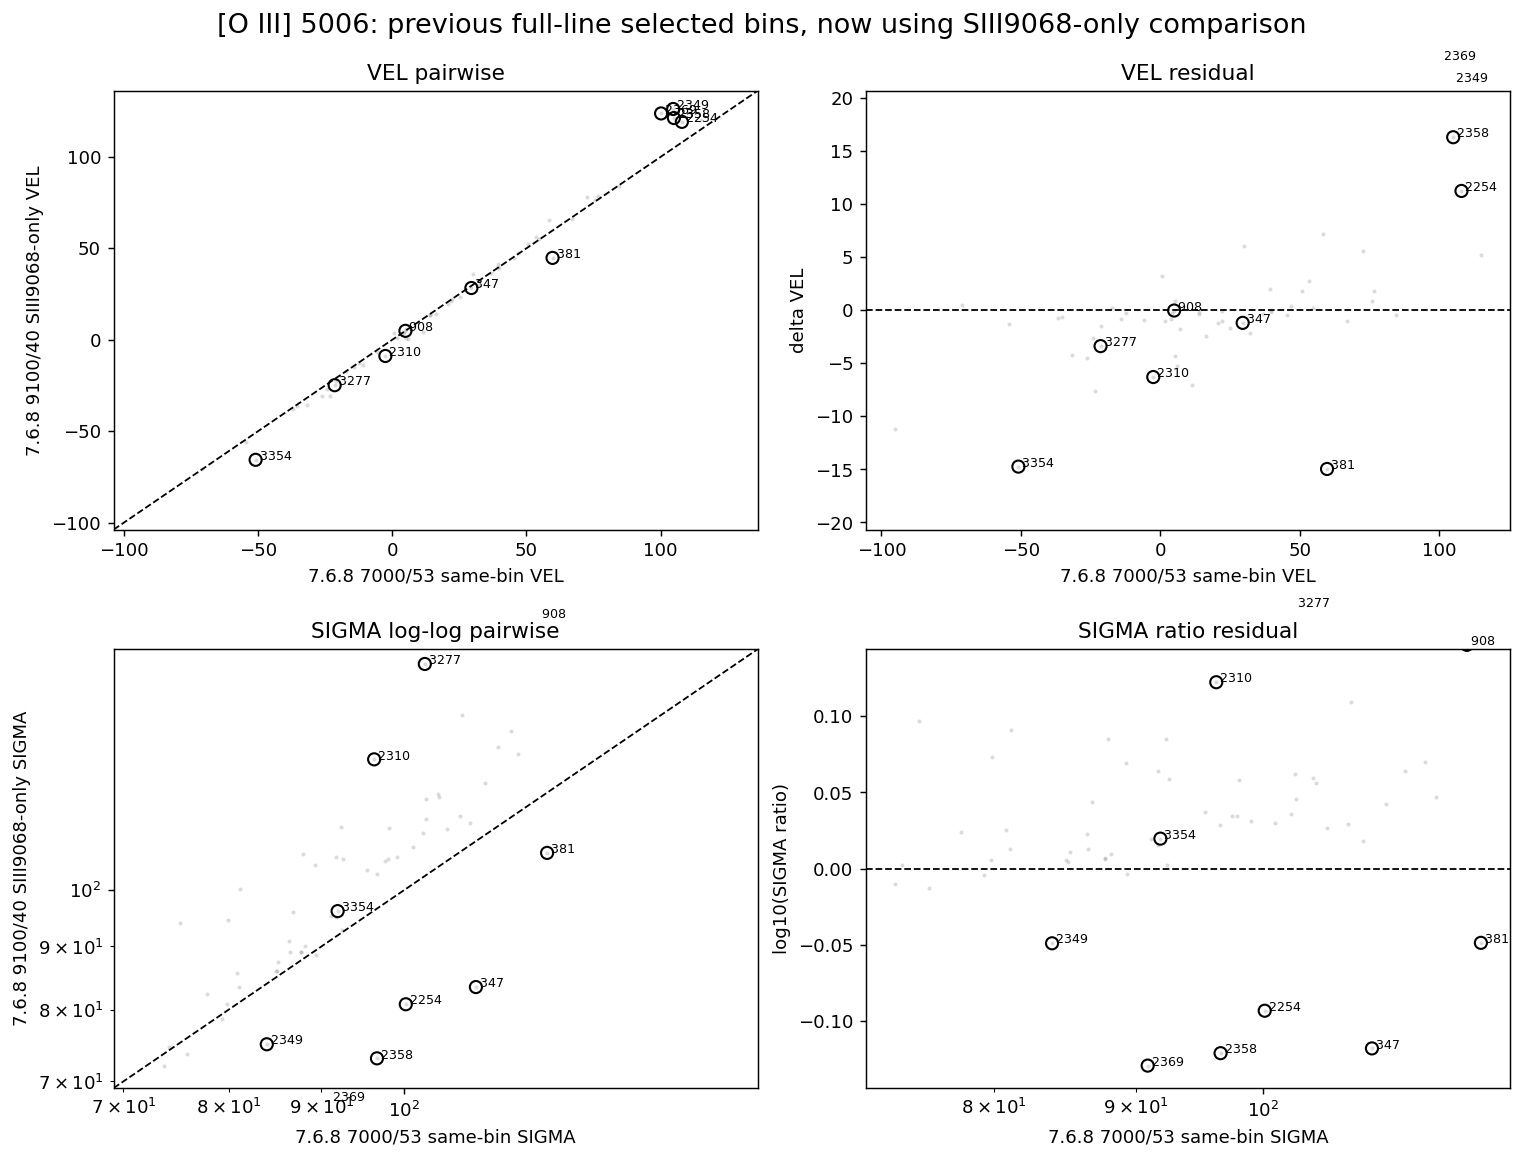

In [10]:
def scatter_highlight_bins(ax, highlight_bins, x_col, y_col, color='black', label_col='bin_id'):
    ax.scatter(highlight_bins[x_col], highlight_bins[y_col], s=45, facecolors='none', edgecolors=color, linewidths=1.15, zorder=5)
    for _, row in highlight_bins.iterrows():
        ax.text(row[x_col], row[y_col], f' {int(row[label_col])}', fontsize=7, color=color, zorder=6)


fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.8), constrained_layout=True)
fig.suptitle(f'{OIII_LABEL}: previous full-line selected bins, now using SIII9068-only comparison', fontsize=15)

plot_sample = high_snr.copy()
if len(plot_sample) > 25000:
    plot_sample = plot_sample.sample(25000, random_state=12)

ax = axes[0, 0]
lo, hi = robust_limits(high_snr[['ref_vel', 'cmp_vel']].to_numpy().ravel(), p=(1, 99), fallback=(-150, 150))
ax.scatter(plot_sample['ref_vel'], plot_sample['cmp_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([lo, hi], [lo, hi], color='black', linestyle='--', linewidth=1)
scatter_highlight_bins(ax, previous_full_line_selected_bins, 'ref_vel', 'cmp_vel')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} VEL')
ax.set_title('VEL pairwise')

ax = axes[0, 1]
vel_lim = symmetric_limit(high_snr['delta_vel'], 98, 25)
ax.scatter(plot_sample['ref_vel'], plot_sample['delta_vel'], s=5, alpha=0.25, linewidths=0, color='0.45')
scatter_highlight_bins(ax, previous_full_line_selected_bins, 'ref_vel', 'delta_vel')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_ylim(-vel_lim, vel_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} VEL')
ax.set_ylabel('delta VEL')
ax.set_title('VEL residual')

ax = axes[1, 0]
sigma_values = high_snr[['ref_sigma', 'cmp_sigma']].to_numpy().ravel()
sigma_values = sigma_values[np.isfinite(sigma_values) & (sigma_values > 0)]
slo_log, shi_log = robust_limits(np.log10(sigma_values), p=(1, 99), fallback=(np.log10(30), np.log10(400)))
slo, shi = 10**slo_log, 10**shi_log
ax.scatter(plot_sample['ref_sigma'], plot_sample['cmp_sigma'], s=5, alpha=0.25, linewidths=0, color='0.45')
ax.plot([slo, shi], [slo, shi], color='black', linestyle='--', linewidth=1)
scatter_highlight_bins(ax, previous_full_line_selected_bins, 'ref_sigma', 'cmp_sigma')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(slo, shi)
ax.set_ylim(slo, shi)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel(f'{RUNS[COMPARE_RUN]["plot_label"]} SIGMA')
ax.set_title('SIGMA log-log pairwise')

ax = axes[1, 1]
log_lim = symmetric_limit(high_snr['log10_sigma_ratio'], 98, 0.3)
ax.scatter(plot_sample['ref_sigma'], plot_sample['log10_sigma_ratio'], s=5, alpha=0.25, linewidths=0, color='0.45')
scatter_highlight_bins(ax, previous_full_line_selected_bins, 'ref_sigma', 'log10_sigma_ratio')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xscale('log')
ax.set_ylim(-log_lim, log_lim)
ax.set_xlabel(f'{RUNS[BASELINE_RUN]["plot_label"]} SIGMA')
ax.set_ylabel('log10(SIGMA ratio)')
ax.set_title('SIGMA ratio residual')

plt.show()


## Real Line-Cube And GAS_BESTFIT Spectral Windows

These panels use the real continuum-subtracted line cube from `v3tk_v7.6.8_7000_samebinning/IC3392/IC3392_line_cube.fits` and the stored `GAS_BESTFIT` spectra from the two comparison runs. The line cube is summed over the same `BIN_ID`; no local continuum subtraction or Gaussian reconstruction is applied here.

Only `OIII5006` and `SIII9068` are shown. A GAS_BESTFIT curve is skipped when that run has no wavelength coverage in the requested window; this matters for `SIII9068`, which sits at the red edge.


In [11]:
def wavelength_from_header(header, n_wave):
    crpix = header.get('CRPIX3', 1.0)
    crval = header.get('CRVAL3')
    cdelt = header.get('CDELT3', header.get('CD3_3'))
    if crval is None or cdelt is None:
        raise ValueError('Cannot construct wavelength vector from cube header.')
    return crval + (np.arange(n_wave) + 1 - crpix) * cdelt


def read_line_cube_slab(line_id):
    spec = LINE_DEFS[line_id]
    rest_air_a = spec['rest_air_a']
    center = rest_air_a * (1.0 + REDSHIFT)
    path = RUNS[LINECUBE_RUN]['line_cube_path']
    with fits.open(path, memmap=True, ignore_missing_end=True) as hdul:
        cube = hdul[0].data
        wave = wavelength_from_header(hdul[0].header, cube.shape[0])
        wave_mask = (wave >= center - spec['wave_half_width']) & (wave <= center + spec['wave_half_width'])
        wave_cut = wave[wave_mask]
        cube_cut = np.array(cube[wave_mask, :, :], dtype=float)
    return wave_cut, cube_cut


def load_gas_bestfit_for_bins(run_key, bin_ids):
    path = RUNS[run_key]['gas_bestfit_path']
    out = {'wave': np.array([]), 'spectra_by_bin': {}, 'n_model_bins': 0}
    if path is None or not path.exists():
        return out
    with fits.open(path, memmap=True, ignore_missing_end=True) as hdul:
        wave = np.exp(np.asarray(hdul['LOGLAM'].data['LOGLAM'], dtype=float)) * (1.0 + REDSHIFT)
        gas_bestfit = hdul['GAS_BESTFIT'].data['GAS_BESTFIT']
        spectra_by_bin = {}
        for bin_id in bin_ids:
            bin_id = int(bin_id)
            if 0 <= bin_id < len(gas_bestfit):
                spectra_by_bin[bin_id] = np.array(gas_bestfit[bin_id], dtype=float)
        out = {'wave': wave, 'spectra_by_bin': spectra_by_bin, 'n_model_bins': len(gas_bestfit)}
    return out


def sideband_rms(wave, spectrum, center, line_half_width):
    sideband = np.abs(wave - center) > line_half_width
    values = np.asarray(spectrum[sideband], dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan
    return robust_sigma(values)


selection_sets = {
    'current_SIII9068_only_selection': {
        'label': 'current SIII9068-only-selected bins',
        'table': selected_bins.head(N_SPECTRA_TO_PLOT).copy(),
        'reason_col': 'selection_reason',
    },
    'previous_full_line_selection': {
        'label': 'previous full-line selected bins',
        'table': previous_full_line_selected_bins.head(N_SPECTRA_TO_PLOT).copy(),
        'reason_col': 'previous_full_line_selection_reason',
    },
}

all_selected_bin_ids = sorted(set(
    int(bin_id)
    for selection in selection_sets.values()
    for bin_id in selection['table']['bin_id'].astype(int).tolist()
))
gas_bestfit_cache = {
    run_key: load_gas_bestfit_for_bins(run_key, all_selected_bin_ids)
    for run_key in BESTFIT_RUNS
}

coverage_rows = []
for line_id in SPECTRAL_LINE_IDS:
    spec = LINE_DEFS[line_id]
    center = spec['rest_air_a'] * (1.0 + REDSHIFT)
    wave_cube, cube_slab = read_line_cube_slab(line_id)
    coverage_rows.append({
        'line_id': line_id,
        'source': 'line_cube',
        'run_label': RUNS[LINECUBE_RUN]['plot_label'],
        'wave_min_a': float(np.nanmin(wave_cube)) if wave_cube.size else np.nan,
        'wave_max_a': float(np.nanmax(wave_cube)) if wave_cube.size else np.nan,
        'n_pixels_in_pm45a_window': int(wave_cube.size),
        'n_pixels_in_line_window': int(np.count_nonzero(np.abs(wave_cube - center) <= spec['line_half_width'])) if wave_cube.size else 0,
        'has_window_coverage': bool(wave_cube.size),
    })
    for run_key in BESTFIT_RUNS:
        wave = gas_bestfit_cache[run_key]['wave']
        window = (wave >= center - spec['wave_half_width']) & (wave <= center + spec['wave_half_width']) if wave.size else np.array([], dtype=bool)
        line_window = np.abs(wave - center) <= spec['line_half_width'] if wave.size else np.array([], dtype=bool)
        coverage_rows.append({
            'line_id': line_id,
            'source': 'GAS_BESTFIT',
            'run_label': RUNS[run_key]['plot_label'],
            'wave_min_a': float(np.nanmin(wave)) if wave.size else np.nan,
            'wave_max_a': float(np.nanmax(wave)) if wave.size else np.nan,
            'n_pixels_in_pm45a_window': int(np.count_nonzero(window)) if wave.size else 0,
            'n_pixels_in_line_window': int(np.count_nonzero(window & line_window)) if wave.size else 0,
            'has_window_coverage': bool(np.count_nonzero(window) > 0),
        })
bestfit_and_linecube_coverage = pd.DataFrame(coverage_rows)
display(bestfit_and_linecube_coverage)


def line_map_stats_for_bin(line_id, bin_id, run_key):
    extnames = set(fits_extnames(RUNS[run_key]['gas_path']))
    required = [f'{line_id}_{suffix}' for suffix in ['FLUX', 'FLUX_ERR', 'VEL', 'SIGMA', 'SIGMA_CORR']]
    if not all(ext in extnames for ext in required):
        return {f'{RUN_PREFIX[run_key]}_{line_id.lower()}_{name}': np.nan for name in ['fluxerr', 'vel', 'sigma', 'sigma_corr']}
    out = {}
    for suffix in ['FLUX', 'FLUX_ERR', 'VEL', 'SIGMA', 'SIGMA_CORR']:
        arr = read_map(RUNS[run_key]['gas_path'], f'{line_id}_{suffix}')
        values = arr[baseline_bins == int(bin_id)]
        values = values[np.isfinite(values)]
        out[suffix.lower()] = float(np.nanmedian(values)) if values.size else np.nan
    fluxerr = out['flux'] / out['flux_err'] if np.isfinite(out['flux']) and np.isfinite(out['flux_err']) and out['flux_err'] > 0 else np.nan
    prefix = RUN_PREFIX[run_key]
    return {
        f'{prefix}_{line_id.lower()}_fluxerr': fluxerr,
        f'{prefix}_{line_id.lower()}_vel': out['vel'],
        f'{prefix}_{line_id.lower()}_sigma': out['sigma'],
        f'{prefix}_{line_id.lower()}_sigma_corr': out['sigma_corr'],
    }


def extract_linecube_bestfit_spectra(line_id, selection_key, selection):
    spec = LINE_DEFS[line_id]
    center = spec['rest_air_a'] * (1.0 + REDSHIFT)
    wave_cube, cube_slab = read_line_cube_slab(line_id)
    spectra = []
    metric_rows = []
    bestfit_rows = []
    if cube_slab.size == 0:
        return spectra, pd.DataFrame(metric_rows), pd.DataFrame(bestfit_rows)

    for _, bin_row in selection['table'].iterrows():
        bin_id = int(bin_row['bin_id'])
        bin_mask = baseline_bins == bin_id
        if not np.any(bin_mask):
            continue
        n_spaxels = int(np.count_nonzero(bin_mask))
        linecube = np.nansum(cube_slab[:, bin_mask], axis=1)
        line_window = np.abs(wave_cube - center) <= spec['line_half_width']
        rms = sideband_rms(wave_cube, linecube, center, spec['line_half_width'])
        peak_abs = float(np.nanmax(np.abs(linecube[line_window]))) if np.any(line_window) else np.nan
        record = {
            'line_id': line_id,
            'selection_key': selection_key,
            'selection_label': selection['label'],
            'selection_reason': bin_row.get(selection['reason_col'], ''),
            'bin_id': bin_id,
            'row': bin_row,
            'wave_cube': wave_cube,
            'linecube': linecube,
            'line_window': line_window,
            'bestfits': {},
        }
        metric = {
            'line_id': line_id,
            'selection_label': selection['label'],
            'selection_reason': bin_row.get(selection['reason_col'], ''),
            'bin_id': bin_id,
            'n_spaxels': n_spaxels,
            'oiii_min_fluxerr': bin_row.get('both_fluxerr_min', np.nan),
            'oiii_delta_vel': bin_row.get('delta_vel', np.nan),
            'oiii_sigma_ratio': bin_row.get('sigma_ratio', np.nan),
            'linecube_sideband_rms': rms,
            'linecube_peak_abs': peak_abs,
            'linecube_peak_abs_over_sideband': peak_abs / rms if np.isfinite(rms) and rms > 0 else np.nan,
        }
        if line_id == 'SIII9068':
            for run_key in BESTFIT_RUNS:
                metric.update(line_map_stats_for_bin(line_id, bin_id, run_key))
        metric_rows.append(metric)

        for run_key in BESTFIT_RUNS:
            cache = gas_bestfit_cache[run_key]
            wave_model = cache['wave']
            model_full = cache['spectra_by_bin'].get(bin_id)
            if wave_model.size == 0 or model_full is None:
                continue
            window = (wave_model >= center - spec['wave_half_width']) & (wave_model <= center + spec['wave_half_width'])
            if not np.any(window):
                bestfit_rows.append({
                    'line_id': line_id,
                    'selection_label': selection['label'],
                    'bin_id': bin_id,
                    'run_label': RUNS[run_key]['plot_label'],
                    'has_window_coverage': False,
                    'n_model_pixels': 0,
                    'n_model_line_window_pixels': 0,
                    'model_peak_abs': np.nan,
                    'model_integral': np.nan,
                    'model_minus_linecube_rms': np.nan,
                })
                continue
            wave_cut = wave_model[window]
            model_cut = np.asarray(model_full[window], dtype=float)
            model_line_window = np.abs(wave_cut - center) <= spec['line_half_width']
            if np.count_nonzero(model_line_window) >= 2:
                model_peak_abs = float(np.nanmax(np.abs(model_cut[model_line_window])))
                model_integral = float(np.trapezoid(model_cut[model_line_window], wave_cut[model_line_window]))
            else:
                model_peak_abs = np.nan
                model_integral = np.nan
            interp_linecube = np.interp(wave_cut, wave_cube, linecube, left=np.nan, right=np.nan)
            compare_mask = model_line_window & np.isfinite(model_cut) & np.isfinite(interp_linecube)
            model_minus_linecube_rms = np.sqrt(np.nanmean((model_cut[compare_mask] - interp_linecube[compare_mask]) ** 2)) if np.count_nonzero(compare_mask) >= 3 else np.nan
            record['bestfits'][run_key] = {
                'wave': wave_cut,
                'model': model_cut,
                'line_window': model_line_window,
                'model_minus_linecube_rms': model_minus_linecube_rms,
            }
            bestfit_rows.append({
                'line_id': line_id,
                'selection_label': selection['label'],
                'bin_id': bin_id,
                'run_label': RUNS[run_key]['plot_label'],
                'has_window_coverage': True,
                'n_model_pixels': int(np.count_nonzero(window)),
                'n_model_line_window_pixels': int(np.count_nonzero(model_line_window)),
                'model_peak_abs': model_peak_abs,
                'model_integral': model_integral,
                'model_minus_linecube_rms': model_minus_linecube_rms,
            })
        spectra.append(record)
    return spectra, pd.DataFrame(metric_rows), pd.DataFrame(bestfit_rows)


linecube_spectra = {}
metric_tables = []
bestfit_metric_tables = []
for selection_key, selection in selection_sets.items():
    linecube_spectra[selection_key] = {}
    for line_id in SPECTRAL_LINE_IDS:
        spectra, metrics, bestfit_metrics = extract_linecube_bestfit_spectra(line_id, selection_key, selection)
        linecube_spectra[selection_key][line_id] = spectra
        metric_tables.append(metrics)
        bestfit_metric_tables.append(bestfit_metrics)
        print(f'Extracted {len(spectra)} {line_id} spectra for {selection["label"]}.')

linecube_metric_table = pd.concat(metric_tables, ignore_index=True) if metric_tables else pd.DataFrame()
bestfit_metric_table = pd.concat(bestfit_metric_tables, ignore_index=True) if bestfit_metric_tables else pd.DataFrame()

linecube_metric_summary = (
    linecube_metric_table
    .groupby(['line_id', 'selection_label'], as_index=False)
    .agg(
        n_spectra=('bin_id', 'size'),
        median_linecube_sideband_rms=('linecube_sideband_rms', 'median'),
        median_linecube_peak_abs_over_sideband=('linecube_peak_abs_over_sideband', 'median'),
        median_oiii_delta_vel=('oiii_delta_vel', 'median'),
        median_oiii_sigma_ratio=('oiii_sigma_ratio', 'median'),
    )
)
display(linecube_metric_summary)

if not bestfit_metric_table.empty:
    bestfit_metric_summary = (
        bestfit_metric_table[bestfit_metric_table['has_window_coverage']]
        .groupby(['line_id', 'selection_label', 'run_label'], as_index=False)
        .agg(
            n_spectra=('bin_id', 'size'),
            median_n_model_pixels=('n_model_pixels', 'median'),
            median_n_model_line_window_pixels=('n_model_line_window_pixels', 'median'),
            median_model_peak_abs=('model_peak_abs', 'median'),
            median_model_integral=('model_integral', 'median'),
            median_model_minus_linecube_rms=('model_minus_linecube_rms', 'median'),
        )
    )
    display(bestfit_metric_summary)

display(linecube_metric_table.sort_values(['selection_label', 'line_id', 'linecube_peak_abs_over_sideband'], ascending=[True, True, False]))


,line_id,source,run_label,wave_min_a,wave_max_a,n_pixels_in_pm45a_window,n_pixels_in_line_window,has_window_coverage
0,OIII5006,line_cube,7.6.8 7000/53 same-bin,4990.000000,5078.750000,72,19,True
1,OIII5006,GAS_BESTFIT,7.6.8 7000/53 same-bin,4827.205076,7038.923514,130,35,True
2,OIII5006,GAS_BESTFIT,7.6.8 9100/40 SIII9068-only,4827.197025,9148.972984,134,36,True
3,SIII9068,line_cube,7.6.8 7000/53 same-bin,9075.000000,9150.000000,61,22,True
4,SIII9068,GAS_BESTFIT,7.6.8 7000/53 same-bin,4827.205076,7038.923514,0,0,False
5,SIII9068,GAS_BESTFIT,7.6.8 9100/40 SIII9068-only,4827.197025,9148.972984,62,23,True


Extracted 10 OIII5006 spectra for current SIII9068-only-selected bins.
Extracted 10 SIII9068 spectra for current SIII9068-only-selected bins.
Extracted 10 OIII5006 spectra for previous full-line selected bins.
Extracted 10 SIII9068 spectra for previous full-line selected bins.


,line_id,selection_label,n_spectra,median_linecube_sideband_rms,median_linecube_peak_abs_over_sideband,median_oiii_delta_vel,median_oiii_sigma_ratio
0,OIII5006,current SIII9068-only-selected bins,10,30.077581,8.771339,-0.616695,0.893568
1,OIII5006,previous full-line selected bins,10,30.077581,8.771339,-0.616695,0.893568
2,SIII9068,current SIII9068-only-selected bins,10,43.366962,5.067148,-0.616695,0.893568
3,SIII9068,previous full-line selected bins,10,43.366962,5.067148,-0.616695,0.893568


,line_id,selection_label,run_label,n_spectra,median_n_model_pixels,median_n_model_line_window_pixels,median_model_peak_abs,median_model_integral,median_model_minus_linecube_rms
0,OIII5006,current SIII9068-only-selected bins,7.6.8 7000/53 same-bin,10,130.0,35.0,263.518176,1052.781148,24.094979
1,OIII5006,current SIII9068-only-selected bins,7.6.8 9100/40 SIII9068-only,10,134.0,36.0,280.356755,1006.883052,29.433328
2,OIII5006,previous full-line selected bins,7.6.8 7000/53 same-bin,10,130.0,35.0,263.518176,1052.781148,24.094979
3,OIII5006,previous full-line selected bins,7.6.8 9100/40 SIII9068-only,10,134.0,36.0,280.356755,1006.883052,29.433328
4,SIII9068,current SIII9068-only-selected bins,7.6.8 9100/40 SIII9068-only,10,62.0,23.0,200.088325,916.896896,47.346652
5,SIII9068,previous full-line selected bins,7.6.8 9100/40 SIII9068-only,10,62.0,23.0,200.088325,916.896896,47.346652


,line_id,selection_label,selection_reason,bin_id,n_spaxels,oiii_min_fluxerr,oiii_delta_vel,oiii_sigma_ratio,linecube_sideband_rms,linecube_peak_abs,linecube_peak_abs_over_sideband,ref_siii9068_fluxerr,ref_siii9068_vel,ref_siii9068_sigma,ref_siii9068_sigma_corr,cmp_siii9068_fluxerr,cmp_siii9068_vel,cmp_siii9068_sigma,cmp_siii9068_sigma_corr
8,OIII5006,current SIII9068-only-selected bins,large velocity difference,381,11,34.976673,-14.965082,0.893873,29.336103,347.939743,11.860462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,OIII5006,current SIII9068-only-selected bins,large velocity difference,2349,10,21.998273,21.512835,0.893264,30.550537,336.478361,11.013828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,OIII5006,current SIII9068-only-selected bins,large sigma ratio,347,11,26.392405,-1.196873,0.762047,26.872058,295.190335,10.985029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,OIII5006,current SIII9068-only-selected bins,large sigma ratio,3277,8,20.713541,-3.389460,1.484373,29.653330,277.526886,9.359046,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,OIII5006,current SIII9068-only-selected bins,large sigma ratio; large velocity difference,2369,16,20.821350,23.579295,0.742492,38.544467,338.144075,8.772830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,OIII5006,current SIII9068-only-selected bins,large sigma ratio,2310,4,20.760708,-6.302466,1.325341,21.296854,186.770176,8.769848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,OIII5006,current SIII9068-only-selected bins,large velocity difference,3354,9,21.685736,-14.742684,1.046314,30.501833,262.943453,8.620579,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,OIII5006,current SIII9068-only-selected bins,large sigma ratio; large velocity difference,2358,10,20.309591,16.293514,0.756585,26.122176,222.589030,8.521075,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,OIII5006,current SIII9068-only-selected bins,large velocity difference,2254,9,20.891518,11.231745,0.806705,31.388282,199.807688,6.365678,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,OIII5006,current SIII9068-only-selected bins,large sigma ratio,908,451,22.660587,-0.036518,1.402275,183.260197,1124.205540,6.134477,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


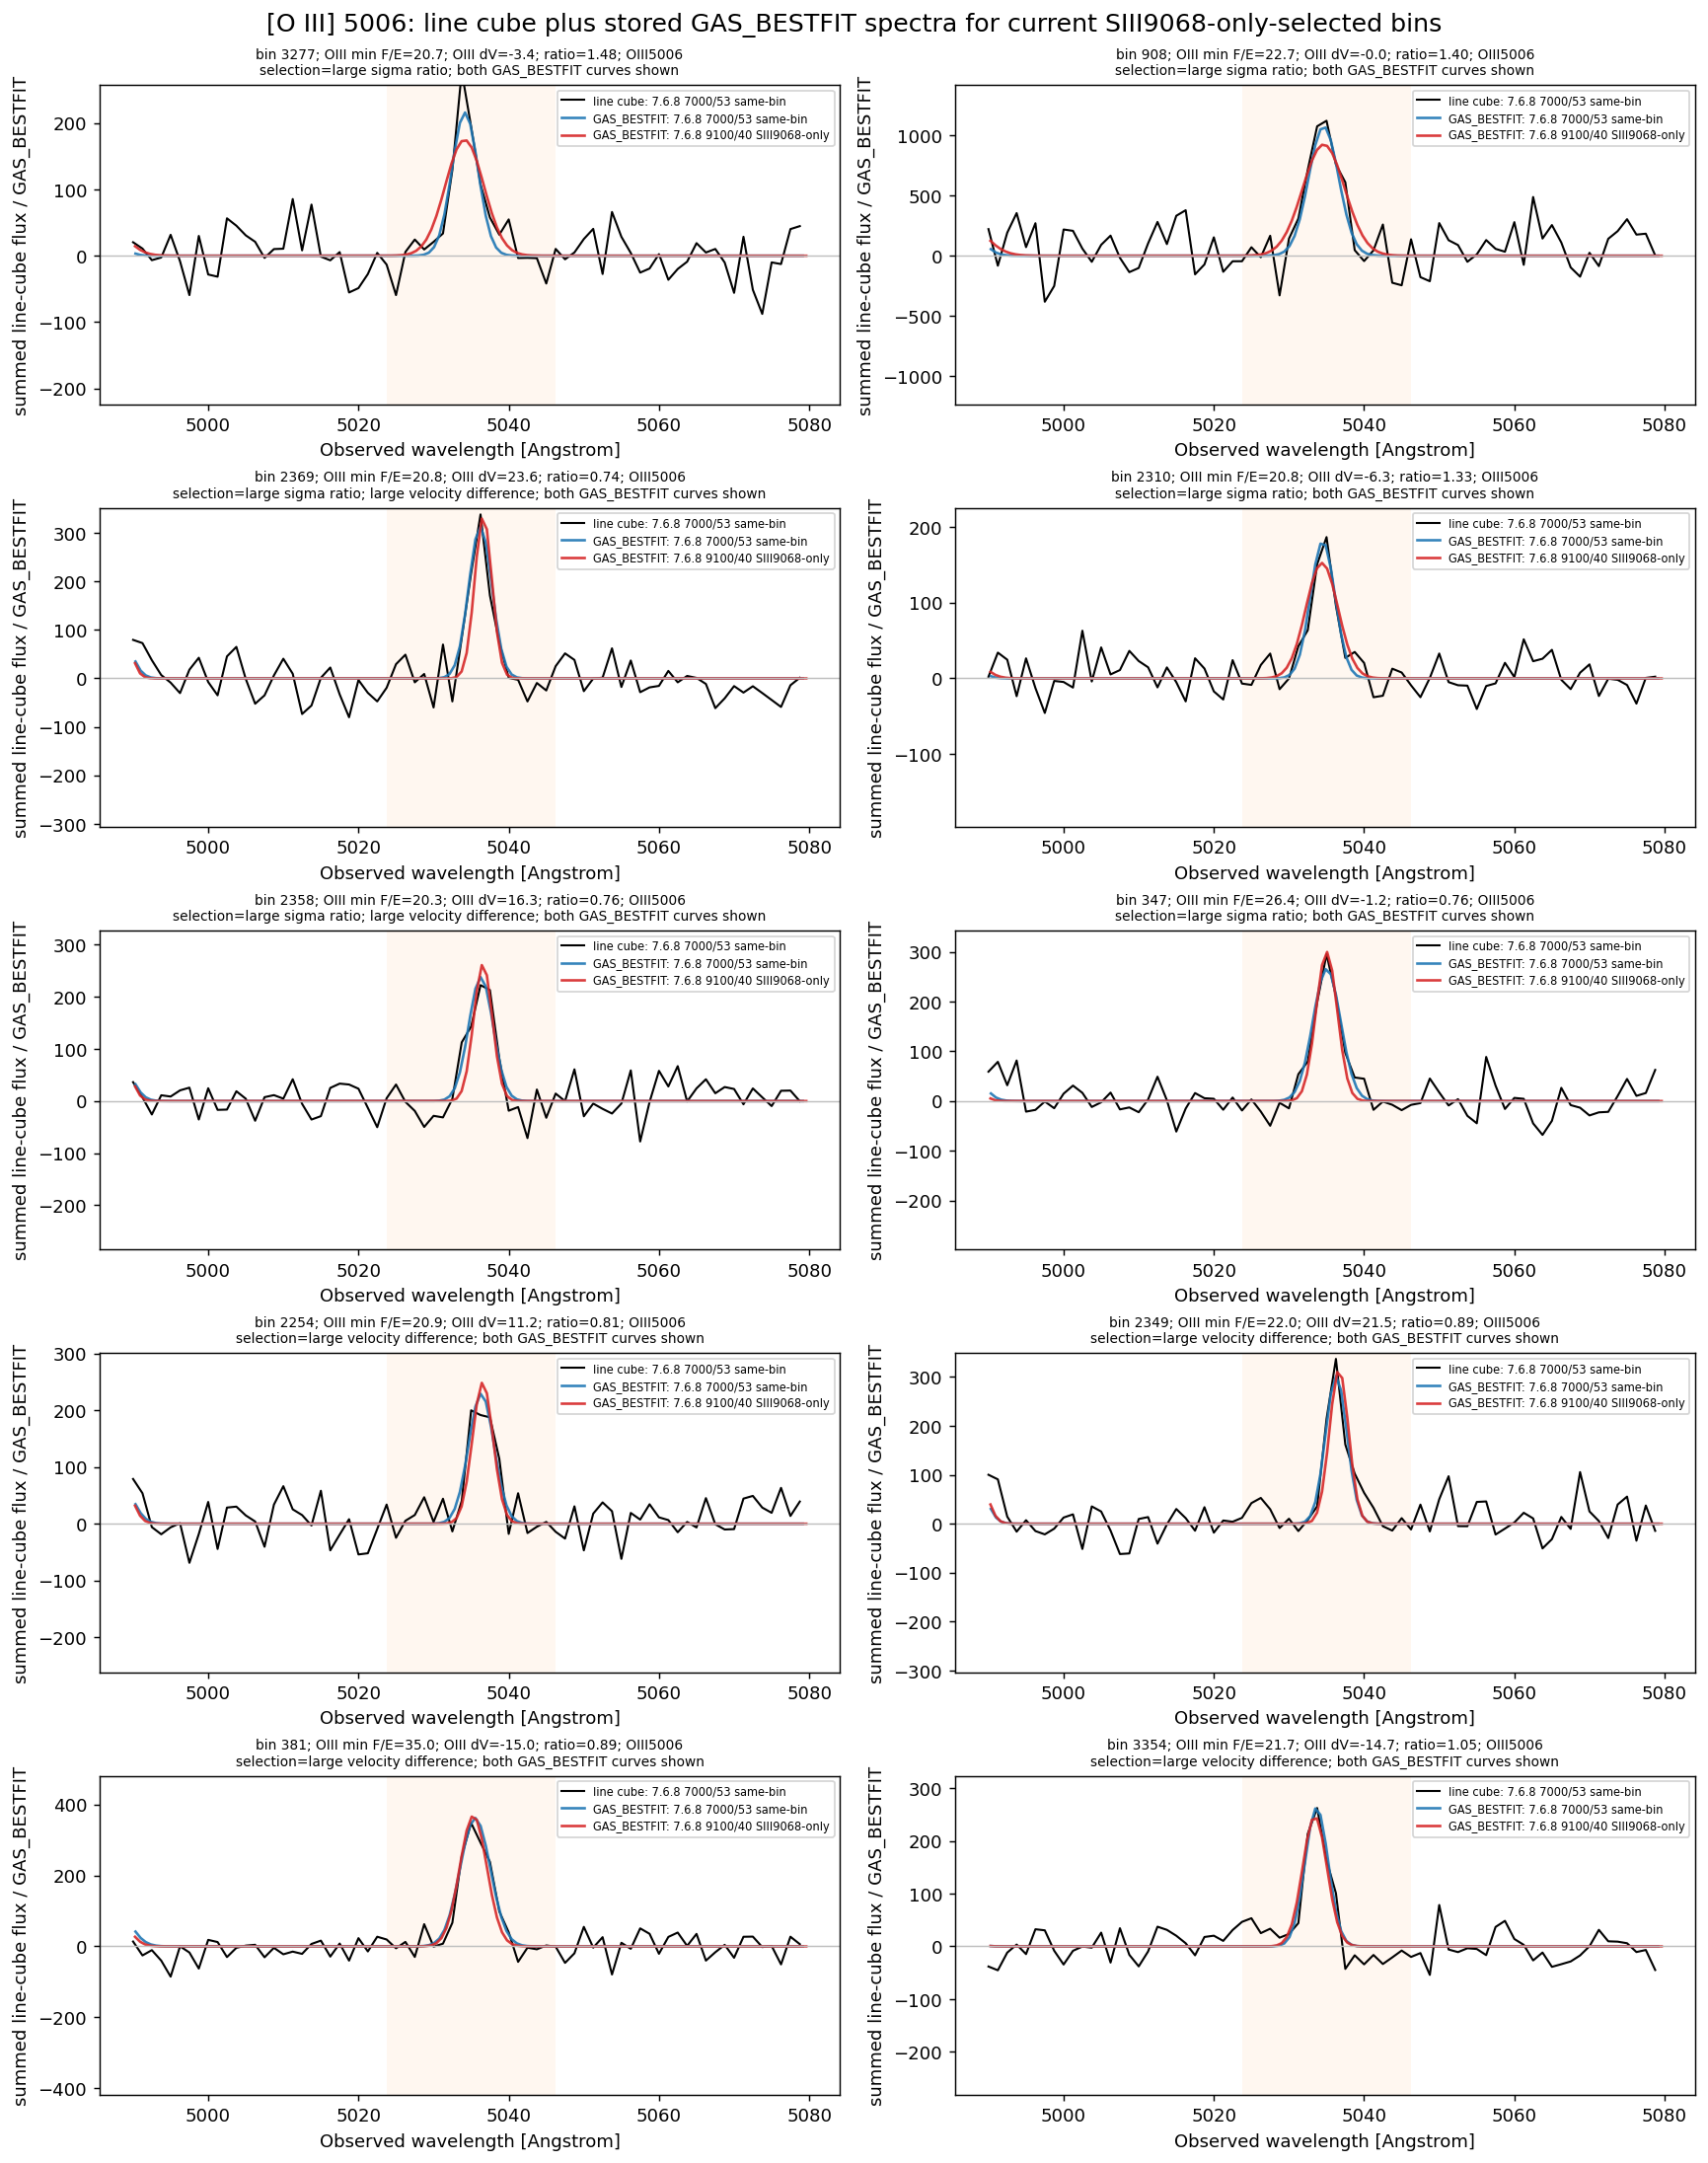

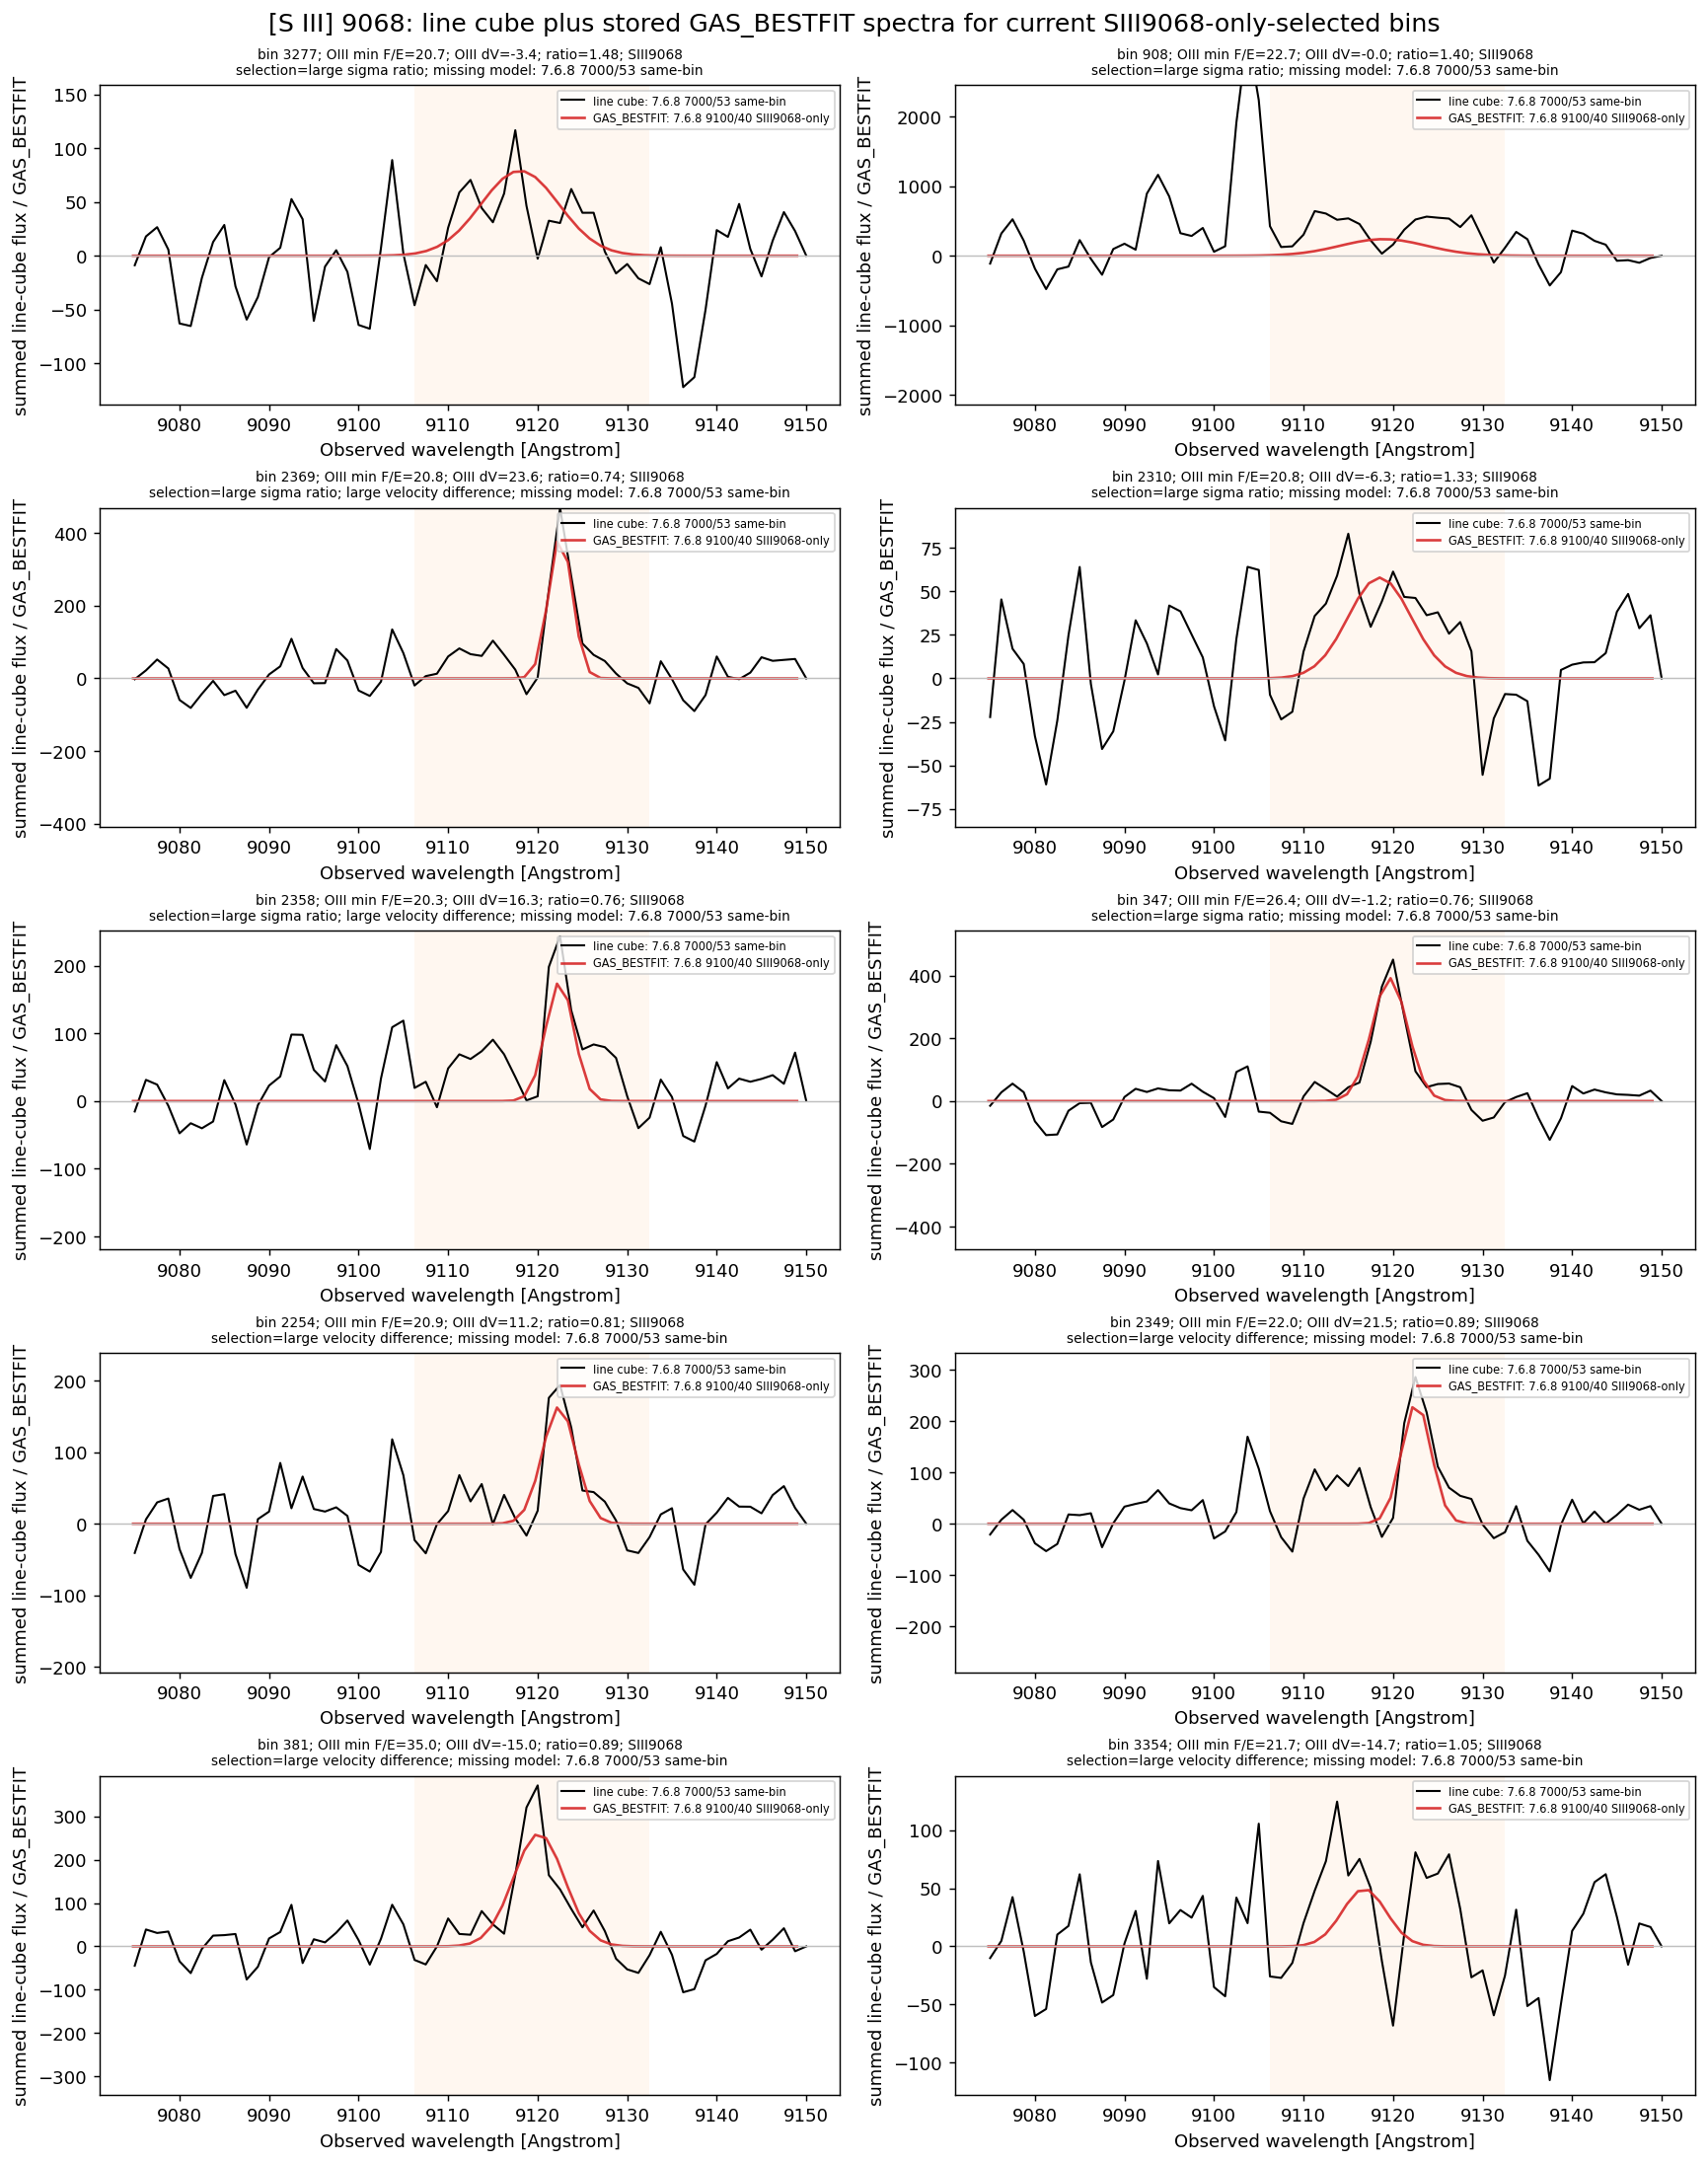

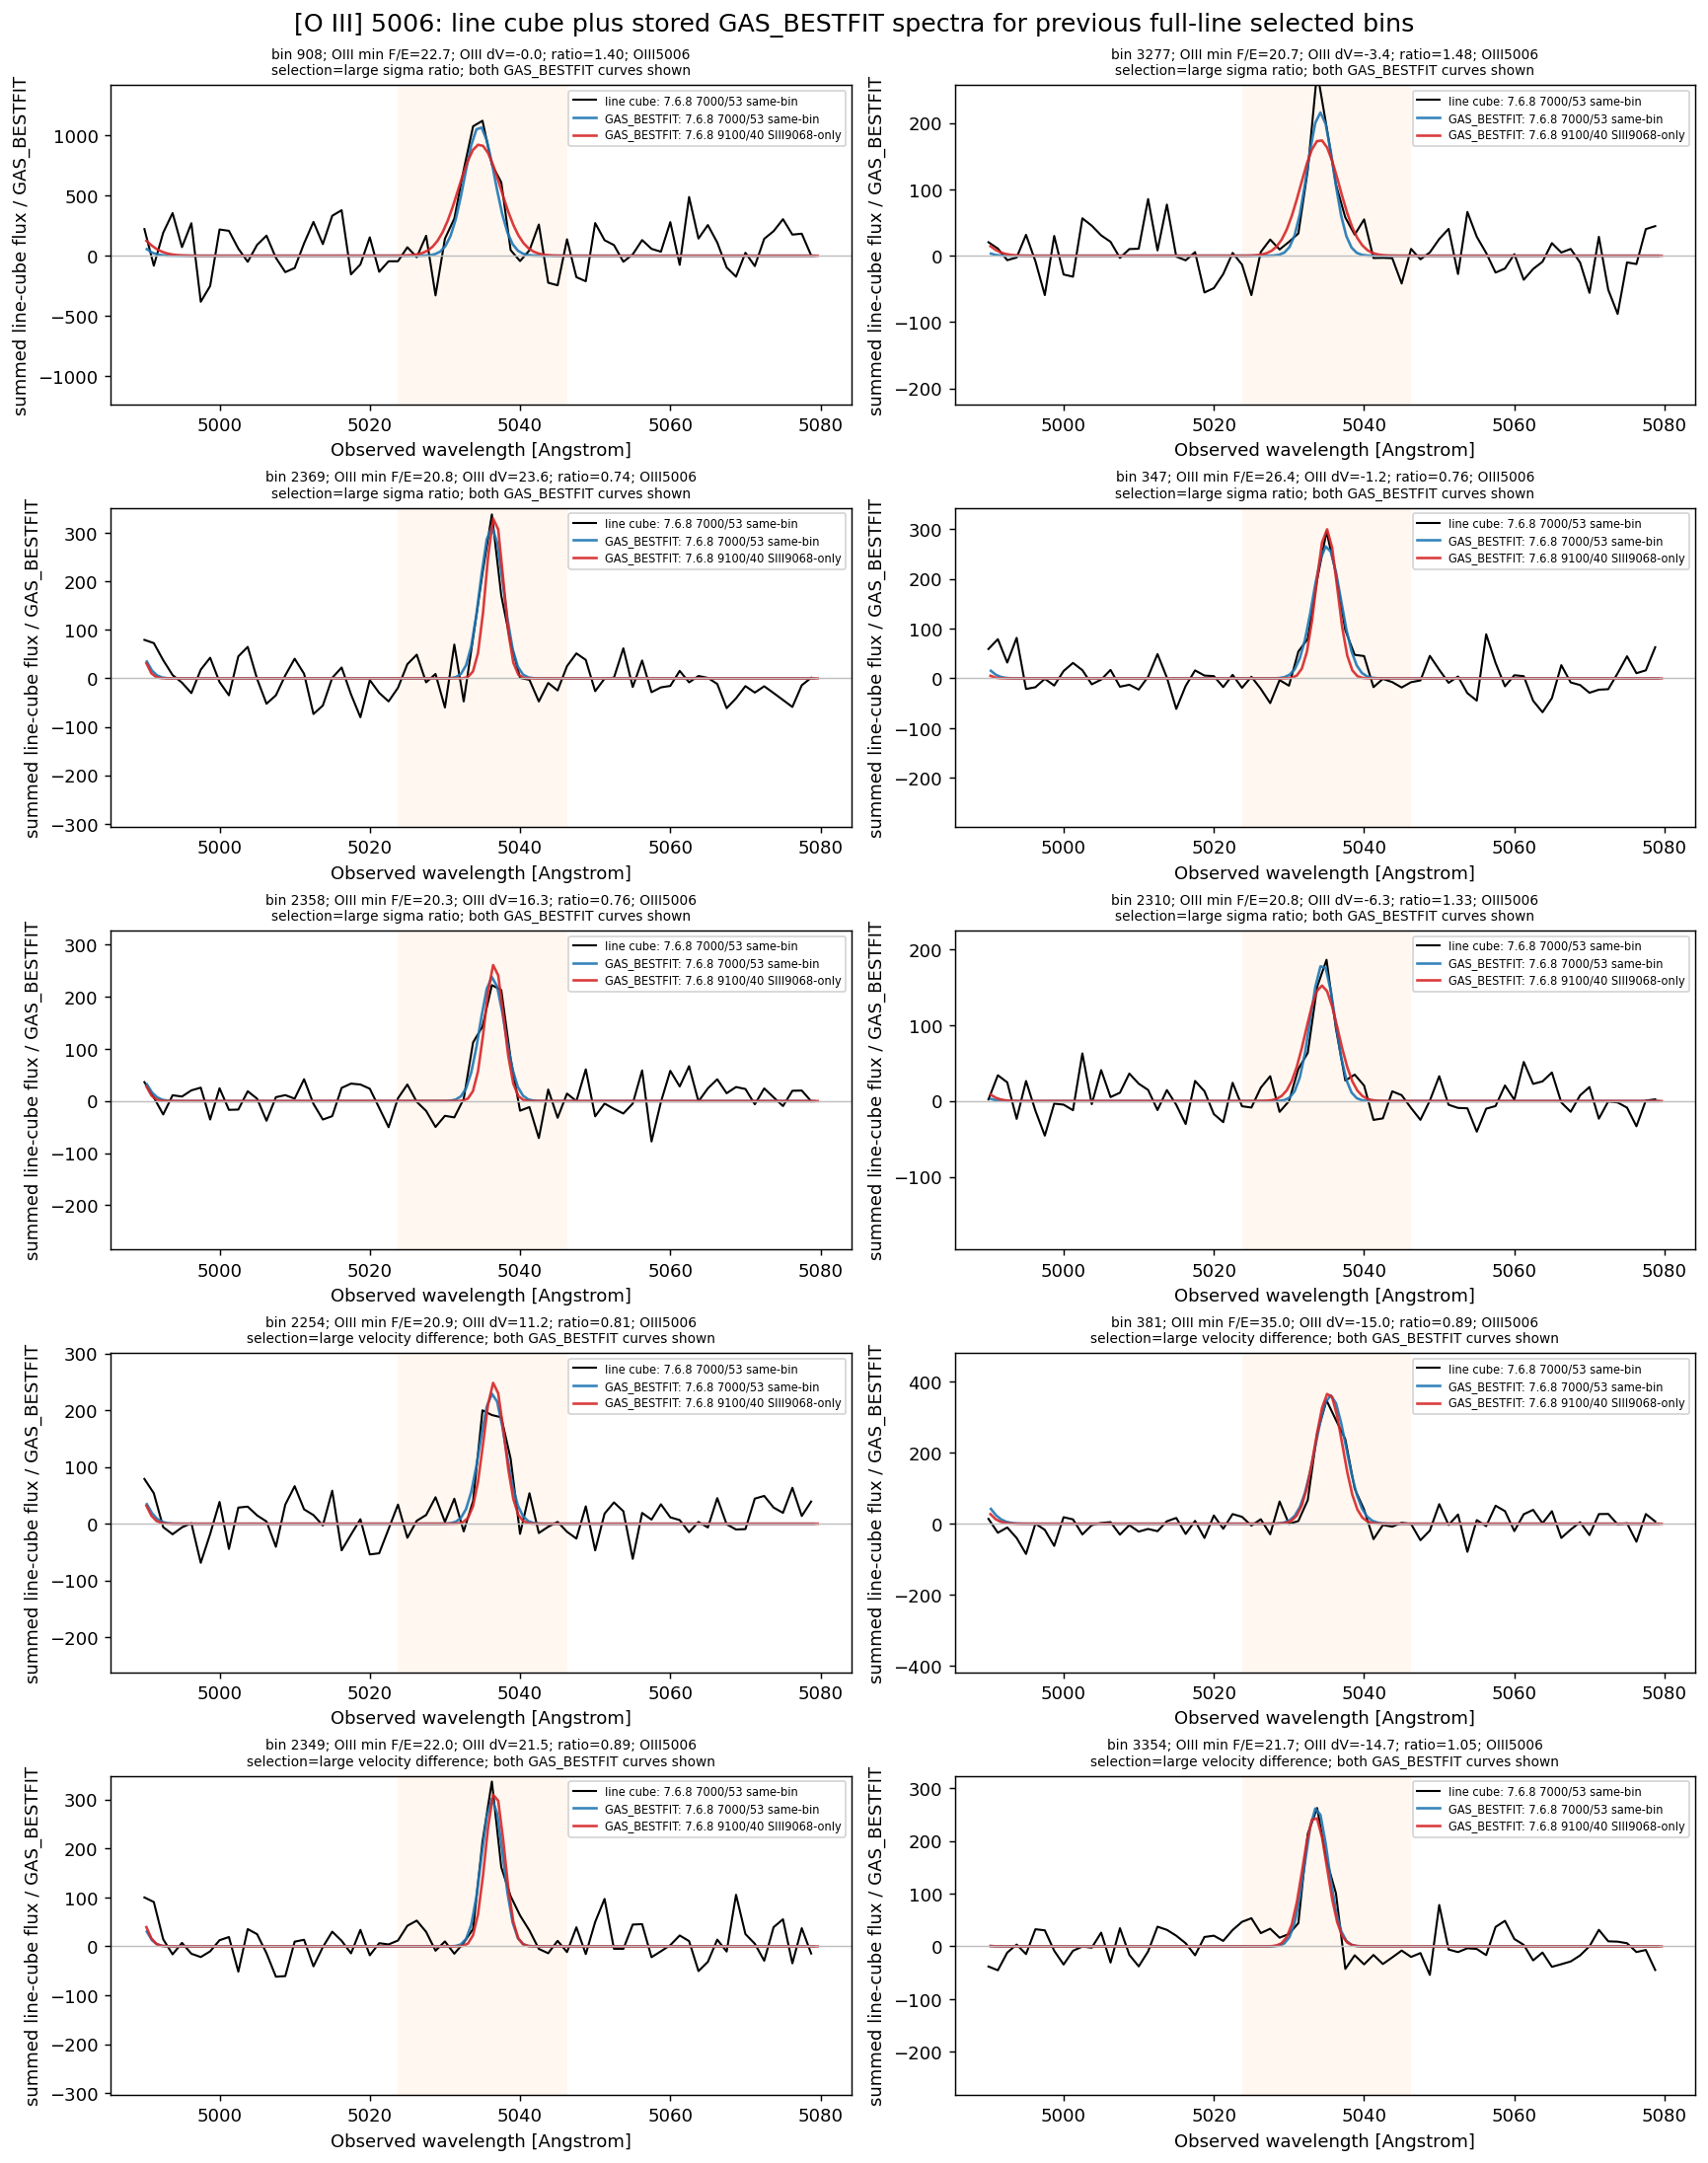

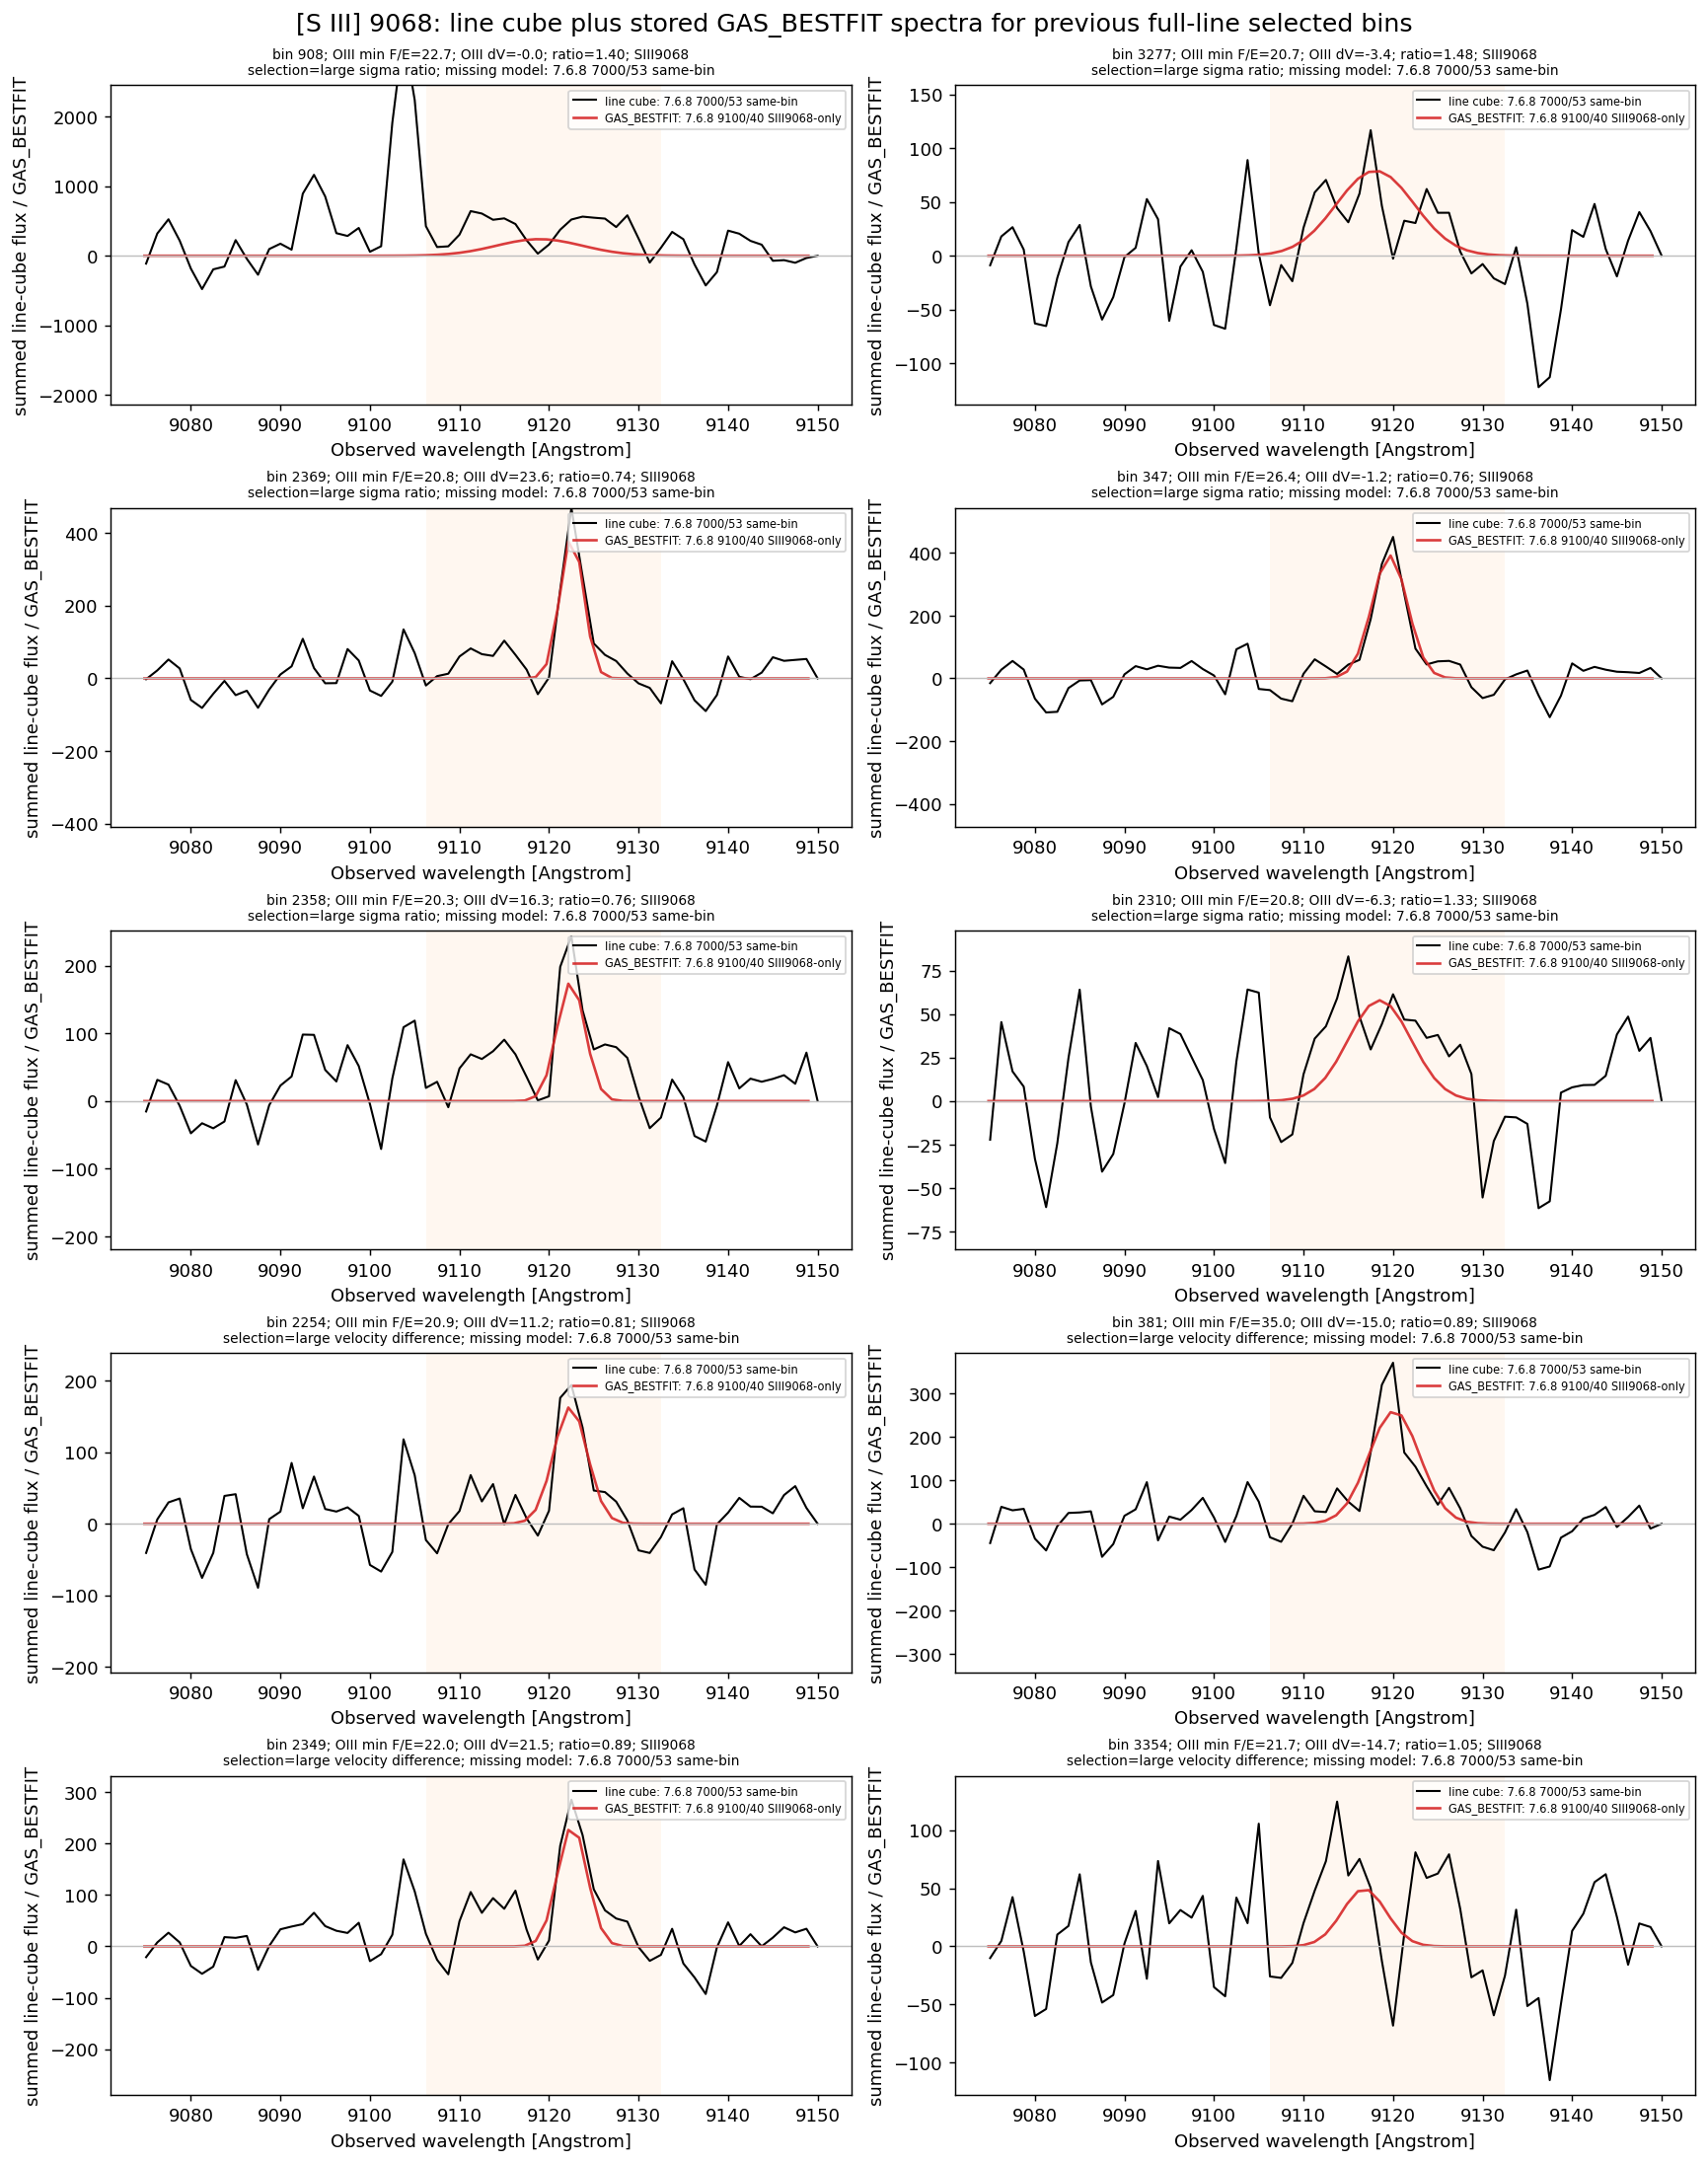

In [12]:
def plot_linecube_bestfit_spectra(selection_key, line_id):
    spectra = linecube_spectra[selection_key][line_id]
    if not spectra:
        print(f'No spectra to plot for {line_id} in {selection_key}.')
        return
    line_label = LINE_DEFS[line_id]['label']
    selection_label = spectra[0]['selection_label']
    n = len(spectra)
    ncols = 2
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13.2, 3.35 * nrows), squeeze=False, constrained_layout=True)
    fig.suptitle(f'{line_label}: line cube plus stored GAS_BESTFIT spectra for {selection_label}', fontsize=14)

    for ax, spec in zip(axes.ravel(), spectra):
        bin_row = spec['row']
        wave_cube = spec['wave_cube']
        linecube = spec['linecube']
        line_window = spec['line_window']
        ax.plot(wave_cube, linecube, color='black', linewidth=1.15, label=f'line cube: {RUNS[LINECUBE_RUN]["plot_label"]}')
        if np.any(line_window):
            ax.axvspan(wave_cube[line_window].min(), wave_cube[line_window].max(), color='tab:orange', alpha=0.06, linewidth=0)

        for run_key in BESTFIT_RUNS:
            fit = spec['bestfits'].get(run_key)
            if fit is None:
                continue
            ax.plot(
                fit['wave'],
                fit['model'],
                color=RUNS[run_key]['color'],
                linewidth=1.45,
                alpha=0.90,
                label=f'GAS_BESTFIT: {RUNS[run_key]["plot_label"]}',
            )

        plotted_values = [linecube[np.isfinite(linecube)]]
        for fit in spec['bestfits'].values():
            plotted_values.append(fit['model'][np.isfinite(fit['model'])])
        finite_values = np.concatenate([values for values in plotted_values if values.size])
        y_scale = np.nanpercentile(np.abs(finite_values), 98) if finite_values.size else 1.0
        y_scale = y_scale if np.isfinite(y_scale) and y_scale > 0 else 1.0
        ax.axhline(0, color='0.75', linewidth=0.8)
        ax.set_ylim(-1.35 * y_scale, 1.55 * y_scale)
        ax.set_xlabel('Observed wavelength [Angstrom]')
        ax.set_ylabel('summed line-cube flux / GAS_BESTFIT')

        missing = [RUNS[run_key]['plot_label'] for run_key in BESTFIT_RUNS if run_key not in spec['bestfits']]
        coverage_note = 'missing model: ' + '; '.join(missing) if missing else 'both GAS_BESTFIT curves shown'
        title = (
            f'bin {int(bin_row["bin_id"])}; OIII min F/E={bin_row["both_fluxerr_min"]:.1f}; '
            f'OIII dV={bin_row["delta_vel"]:.1f}; ratio={bin_row["sigma_ratio"]:.2f}; {line_id}'
        )
        subtitle = f'selection={spec["selection_reason"]}; {coverage_note}'
        ax.set_title(title + '\n' + subtitle, fontsize=7.6)
        ax.legend(loc='upper right', fontsize=6.3, frameon=True)

    for ax in axes.ravel()[len(spectra):]:
        ax.axis('off')
    plt.show()


for selection_key in selection_sets:
    for line_id in SPECTRAL_LINE_IDS:
        plot_linecube_bestfit_spectra(selection_key, line_id)


## Optional Save

Uncomment these lines if you want CSV tables for follow-up notes or manual inspection.


In [13]:
# population_summary.to_csv('IC3392_OIII_fluxerr_population_20260515_use_SIII9068.csv', index=False)
# selected_bins[selected_cols].to_csv('IC3392_OIII_highSN_selected_outlier_bins_20260515_use_SIII9068.csv', index=False)
# bin_table.to_csv('IC3392_OIII_one_row_per_bin_20260515_use_SIII9068.csv', index=False)
# SIII9068_only_context.to_csv('IC3392_OIII_context_20260515_use_SIII9068.csv', index=False)
# linecube_metric_table.to_csv('IC3392_linecube_metrics_20260515_use_SIII9068.csv', index=False)
# bestfit_metric_table.to_csv('IC3392_gas_bestfit_metrics_20260515_use_SIII9068.csv', index=False)
